# Notebook 04 — Substation Coverage, Load Profiles, and EIA Comparison

Five sections:
1. **Substation universe** — how many substations we have vs the full California grid, mapped by utility/BA
2. **Aggregate load profiles by utility** — summed min/max load by month and hour
3. **Load vs generation capacity ratios** — how substation peaks compare to DER capacity (PGE, SCE, SDGE)
4. **EIA regional time series** — hourly demand, net generation, and interchange per BA and for CAL aggregate
5. **Interchange balance** — implied generation vs demand; how large net inflows/outflows swing
6. **Substation aggregate vs EIA demand** — comparing non-contemporaneous substation peaks to actual hourly EIA demand


**BA boundary reference**: https://www.gridstatus.io/ba-map

In [80]:
from pathlib import Path
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.colors as mcolors

warnings.filterwarnings('ignore')

ROOT  = Path().resolve().parent
PROC  = ROOT / 'data' / 'processed'

# ── Load all datasets ─────────────────────────────────────────────────────────
print('Loading substation load profiles ...')
lp  = pd.read_csv(PROC / 'substations' / 'substation_load_profiles.csv', low_memory=False)
print(f'  {len(lp):,} rows  ({lp.utility.value_counts().to_dict()})')

print('Loading substation locations ...')
loc = pd.read_csv(PROC / 'substations' / 'substation_locations.csv', low_memory=False)
for col in ['existing_gen', 'queued_gen', 'total_gen', 'projected_load']:
    loc[col] = pd.to_numeric(loc[col], errors='coerce')
print(f'  {len(loc):,} rows  ({loc.utility.value_counts().to_dict()})')

print('Loading EIA region data ...')
reg = pd.read_csv(PROC / 'eia' / 'eia_region.csv', low_memory=False)
reg['dt'] = pd.to_datetime(reg['period'].str[:13], format='%Y-%m-%dT%H')
reg['hour'] = reg['dt'].dt.hour
reg['month'] = reg['dt'].dt.month
reg['year'] = reg['dt'].dt.year
print(f'  {len(reg):,} rows  respondents: {sorted(reg.respondent.unique())}')

print('Loading EIA interchange data ...')
ic = pd.read_csv(PROC / 'eia' / 'eia_interchange.csv', low_memory=False)
ic['dt'] = pd.to_datetime(ic['period'].str[:13], format='%Y-%m-%dT%H')
print(f'  {len(ic):,} rows')

CA8 = ['BANC', 'CISO', 'IID', 'LDWP', 'NEVP', 'PACW', 'TIDC', 'WALC']
IOU3 = ['pge', 'sce', 'sdge']
# Approximate utility-to-BA mapping (not all substations fall neatly within one BA)
UTIL_COLOR = {'pge': 'steelblue', 'sce': 'tomato', 'sdge': 'seagreen', 'pacificorp': 'goldenrod'}
BA_COLOR   = dict(zip(CA8, plt.cm.tab10.colors[:8]))

Loading substation load profiles ...
  455,568 rows  ({'sce': 235872, 'pge': 191184, 'sdge': 28512})
Loading substation locations ...
  2,614 rows  ({'pacificorp': 1142, 'sce': 709, 'pge': 664, 'sdge': 99})
Loading EIA region data ...
  520,116 rows  respondents: ['BANC', 'CISO', 'IID', 'LDWP', 'NEVP', 'PACW', 'TIDC', 'WALC']
Loading EIA interchange data ...
  3,070,823 rows


In [81]:
reg['test'] = reg['demand'] -reg['net_gen'] + reg['total_interchange']
reg.loc[reg['test'].abs() < 10].groupby('respondent').count()/reg.groupby('respondent').count()
# reg.groupby('respondent')['test'].agg(['min','max','mean','std'])

# len(reg[reg['test'].abs() > 100])/len(reg)

,period,respondent-name,demand,demand_forecast,net_gen,total_interchange,dt,hour,month,year,test
respondent,,,,,,,,,,,
BANC,0.928407,0.928407,0.928578,0.928265,0.928849,0.933934,0.928407,0.928407,0.928407,0.928407,0.934050
CISO,0.004858,0.004858,0.004860,0.004867,0.004863,0.004898,0.004858,0.004858,0.004858,0.004858,0.004900
IID,0.731178,0.731178,0.731763,0.734145,0.735832,0.741043,0.731178,0.731178,0.731178,0.731178,0.741899
LDWP,0.993976,0.993976,0.994436,0.996108,0.994758,0.995126,0.993976,0.993976,0.993976,0.993976,0.995126
NEVP,0.872336,0.872336,0.872390,0.872210,0.873975,0.872994,0.872336,0.872336,0.872336,0.872336,0.874299
PACW,0.973650,0.973650,0.973710,0.973650,0.974025,0.974025,0.973650,0.973650,0.973650,0.973650,0.974025
TIDC,0.978877,0.978877,0.981125,0.979479,0.981790,0.987561,0.978877,0.978877,0.978877,0.978877,0.987577
WALC,0.991616,0.991616,0.993144,0.991608,0.993144,0.998266,0.991616,0.991616,0.991616,0.991616,0.998297


---
## Section 1 — Substation Universe and Coverage

California's distribution grid spans six investor-owned utilities.  We have load data
for three (PG&E, SCE, SDG&E) and location/attribute data for PacifiCorp.  CalPeco
(Liberty Utilities) and BVES have no public data source identified yet.

For BA boundaries see: https://www.gridstatus.io/ba-map

In [82]:
# Coverage summary table
loc_counts   = loc.groupby('utility').size().rename('locations')
load_counts  = lp.groupby('utility')['substation_name'].nunique().rename('with_load_data')
coord_counts = loc[loc[['latitude','longitude']].notna().all(axis=1)].groupby('utility').size().rename('with_coords')
volt_counts  = loc[loc['voltage_kv'].notna()].groupby('utility').size().rename('with_voltage')
gen_counts   = loc[loc['existing_gen'].notna() & (loc['existing_gen'] > 0)].groupby('utility').size().rename('with_existing_gen')

summary = pd.concat([loc_counts, load_counts, coord_counts, volt_counts, gen_counts], axis=1).fillna(0).astype(int)
summary.index.name = 'utility'
print('Substation data coverage:')
print(summary.to_string())
print()
print('Total substations with any load data:', lp[lp.utility.isin(IOU3)]['substation_name'].nunique())
print('Missing from coverage: CalPeco (Liberty Utilities), BVES — no public data source identified')

Substation data coverage:
            locations  with_load_data  with_coords  with_voltage  with_existing_gen
utility                                                                            
pacificorp       1142               0         1142             0                  0
pge               664             664          664           664                654
sce               709             709          697           542                652
sdge               99              99           99            99                 99

Total substations with any load data: 1465
Missing from coverage: CalPeco (Liberty Utilities), BVES — no public data source identified


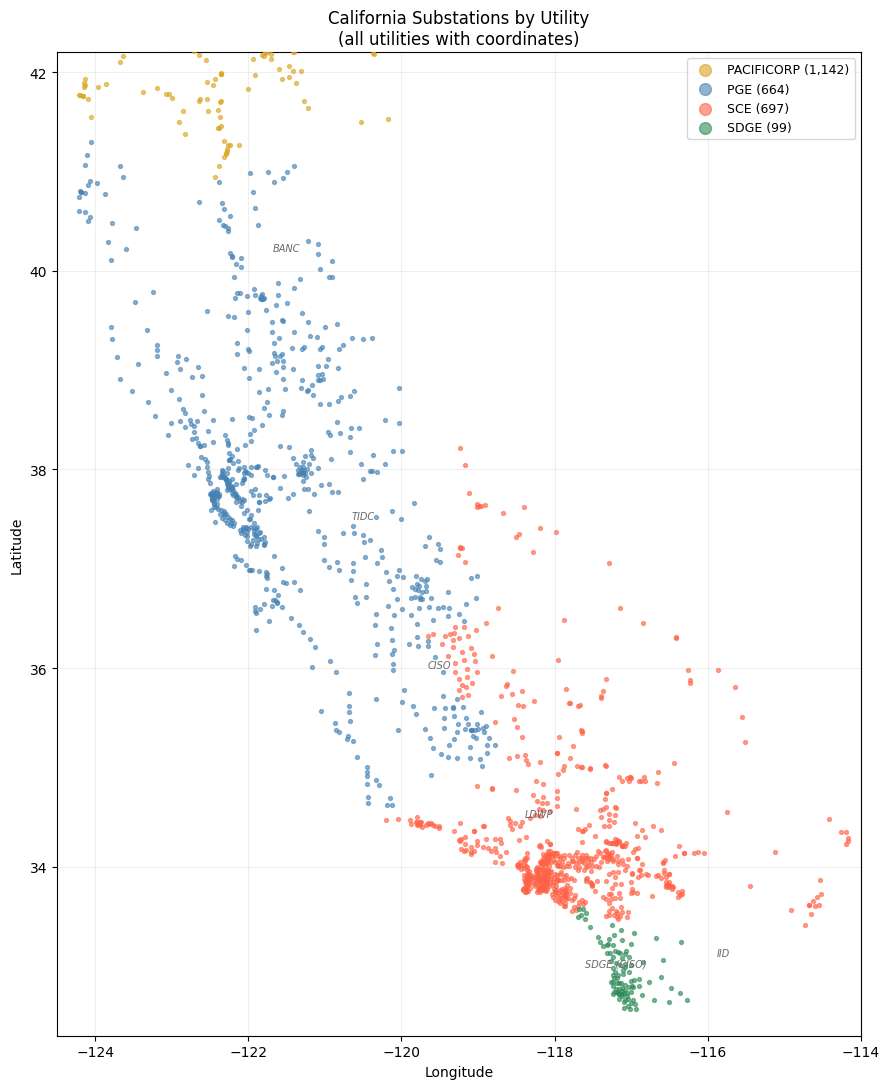

In [83]:
# Map: all substations with coordinates, colored by utility
# Approximate CA BA boundaries shown as annotations
fig, ax = plt.subplots(figsize=(9, 11))

for util, grp in loc.dropna(subset=['latitude','longitude']).groupby('utility'):
    ax.scatter(
        grp['longitude'], grp['latitude'],
        s=8, alpha=0.6, label=f'{util.upper()} ({len(grp):,})',
        color=UTIL_COLOR.get(util, 'grey'), zorder=3,
    )

# Rough California state outline extent
ax.set_xlim(-124.5, -114.0)
ax.set_ylim(32.3, 42.2)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('California Substations by Utility\n(all utilities with coordinates)')
ax.legend(loc='upper right', markerscale=3, fontsize=9)
ax.grid(True, alpha=0.2)

# Annotate approximate BA regions
for label, xy in [
    ('BANC', (-121.5, 40.2)),
    ('TIDC', (-120.5, 37.5)),
    ('CISO', (-119.5, 36.0)),
    ('LDWP', (-118.2, 34.5)),
    ('IID',  (-115.8, 33.1)),
    ('SDGE (CISO)', (-117.2, 33.0)),
]:
    ax.annotate(label, xy, fontsize=7, color='dimgray',
                ha='center', style='italic')

plt.tight_layout()
plt.show()

---
## Section 2 — Aggregate Load Profiles by Utility

Sum all substation loads by (utility, month, hour) to see the total system curve
shape for each utility.  Seasonal variation and the solar duck-curve dip should
appear clearly for SCE and SDG&E.

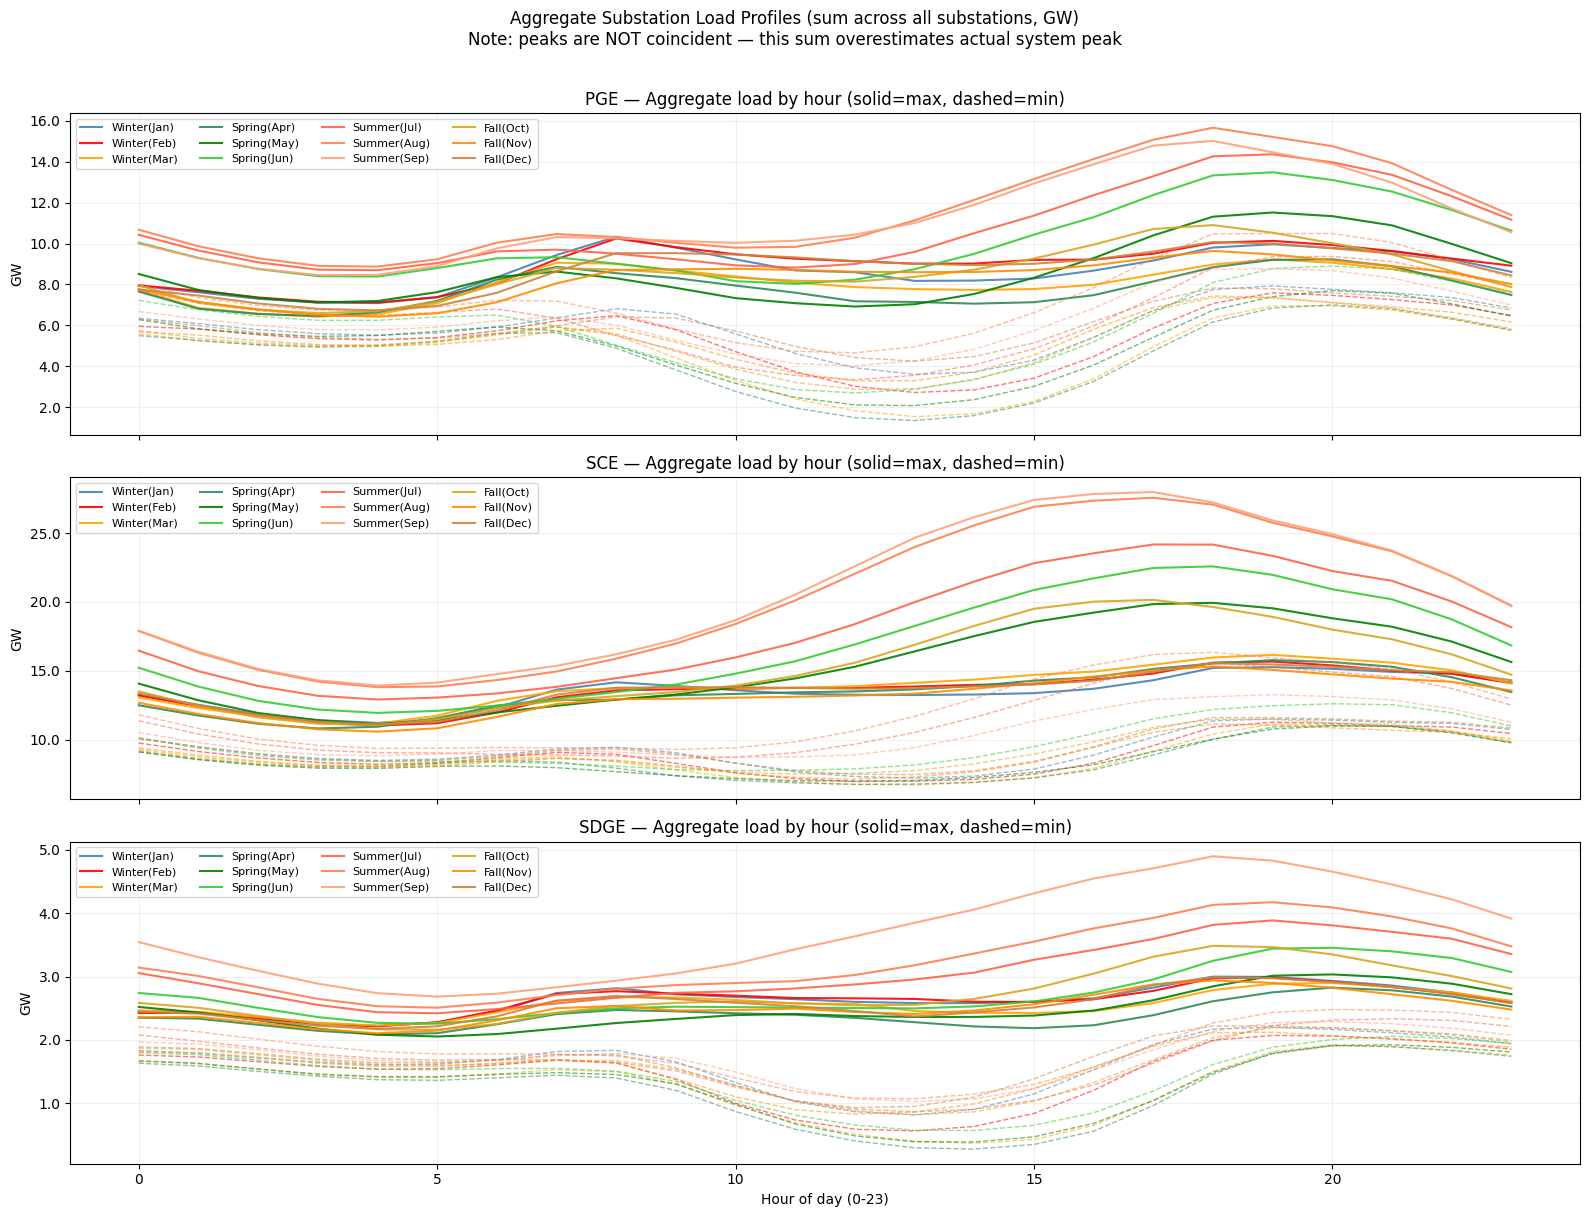

In [84]:
# Aggregate: sum across all substations for each (utility, month, hour)
agg = (
    lp[lp.utility.isin(IOU3)]
    .groupby(['utility', 'month', 'hour'])[['min_load', 'max_load']]
    .sum()
    .reset_index()
)

fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)
seasons = {1:'Winter(Jan)',2:'Winter(Feb)',3:'Winter(Mar)', 
           4:'Spring(Apr)',5:'Spring(May)',6:'Spring(Jun)',
           7:'Summer(Jul)',8:'Summer(Aug)',9:'Summer(Sep)',
          10:'Fall(Oct)',11:'Fall(Nov)',12:'Fall(Dec)'}

color = {1:'steelblue', 2:'red', 3:'orange', 
        4:'seagreen', 5:'green', 6:'limegreen',
        7:'tomato', 8:'coral', 9:'lightsalmon',
        10:'goldenrod', 11:'darkorange', 12:'peru'}

for i, util in enumerate(IOU3):
    ax = axes[i]
    d = agg[agg.utility == util]
    for month, label in seasons.items():
        row = d[d.month == month]
        alpha = 0.9
        # ax.fill_between(row.hour, row.min_load/1000, row.max_load/1000,
        #                 alpha=0.15, color=UTIL_COLOR[util])
        ax.plot(row.hour, row.max_load/1000, label=label, alpha=alpha, lw=1.5, color=color[month])
        ax.plot(row.hour, row.min_load/1000, alpha=alpha*0.6, lw=1, ls='--', color=color[month])
    ax.set_title(f'{util.upper()} — Aggregate load by hour (solid=max, dashed=min)')
    ax.set_ylabel('GW')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}'))
    ax.legend(ncol=4, fontsize=8)
    ax.grid(True, alpha=0.2)

axes[-1].set_xlabel('Hour of day (0-23)')
plt.suptitle('Aggregate Substation Load Profiles (sum across all substations, GW)\nNote: peaks are NOT coincident — this sum overestimates actual system peak', y=1.01)
plt.tight_layout()
plt.show()

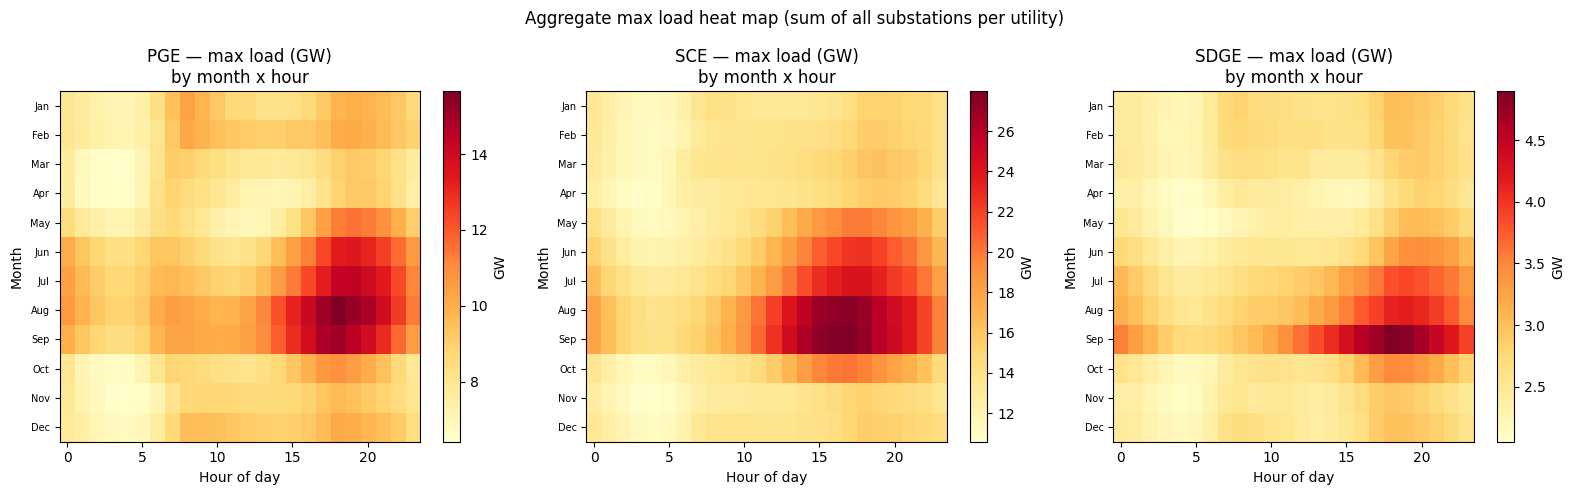

In [85]:
# Heat map: month vs hour for each utility (max_load)
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, util in zip(axes, IOU3):
    pivot = (
        agg[agg.utility == util]
        .pivot(index='month', columns='hour', values='max_load') / 1000
    )
    im = ax.imshow(pivot, aspect='auto', cmap='YlOrRd', origin='upper')
    ax.set_title(f'{util.upper()} — max load (GW)\nby month x hour')
    ax.set_xlabel('Hour of day')
    ax.set_ylabel('Month')
    ax.set_yticks(range(12))
    ax.set_yticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'], fontsize=7)
    plt.colorbar(im, ax=ax, label='GW')

plt.suptitle('Aggregate max load heat map (sum of all substations per utility)')
plt.tight_layout()
plt.show()

### Section 2b — Aggregate Load vs IEPR 2025 Projections

IEPR (CEC Integrated Energy Policy Report) publishes projected peak-day loads for each
transmission access charge area (TAC = PGE, SCE, SDGE) for every forecast year.

Here we compare the substation aggregate against IEPR 2025 `UNADJUSTED_CONSUMPTION`
and `MANAGED_NET_LOAD` (which includes demand response and energy efficiency adjustments)
for each of the 288 month-hours (12 months × 24 hours), using the **TAC peak-day** scenario
(`COINCIDENT=False`, `Local_Reliability`).

The shaded band runs from **sum of all substations' min loads** (p10 proxy — lower bound)
to **sum of all substations' max loads** (p90 proxy — upper bound).  Because substation
peaks are not coincident, the upper bound exceeds actual system load by definition.

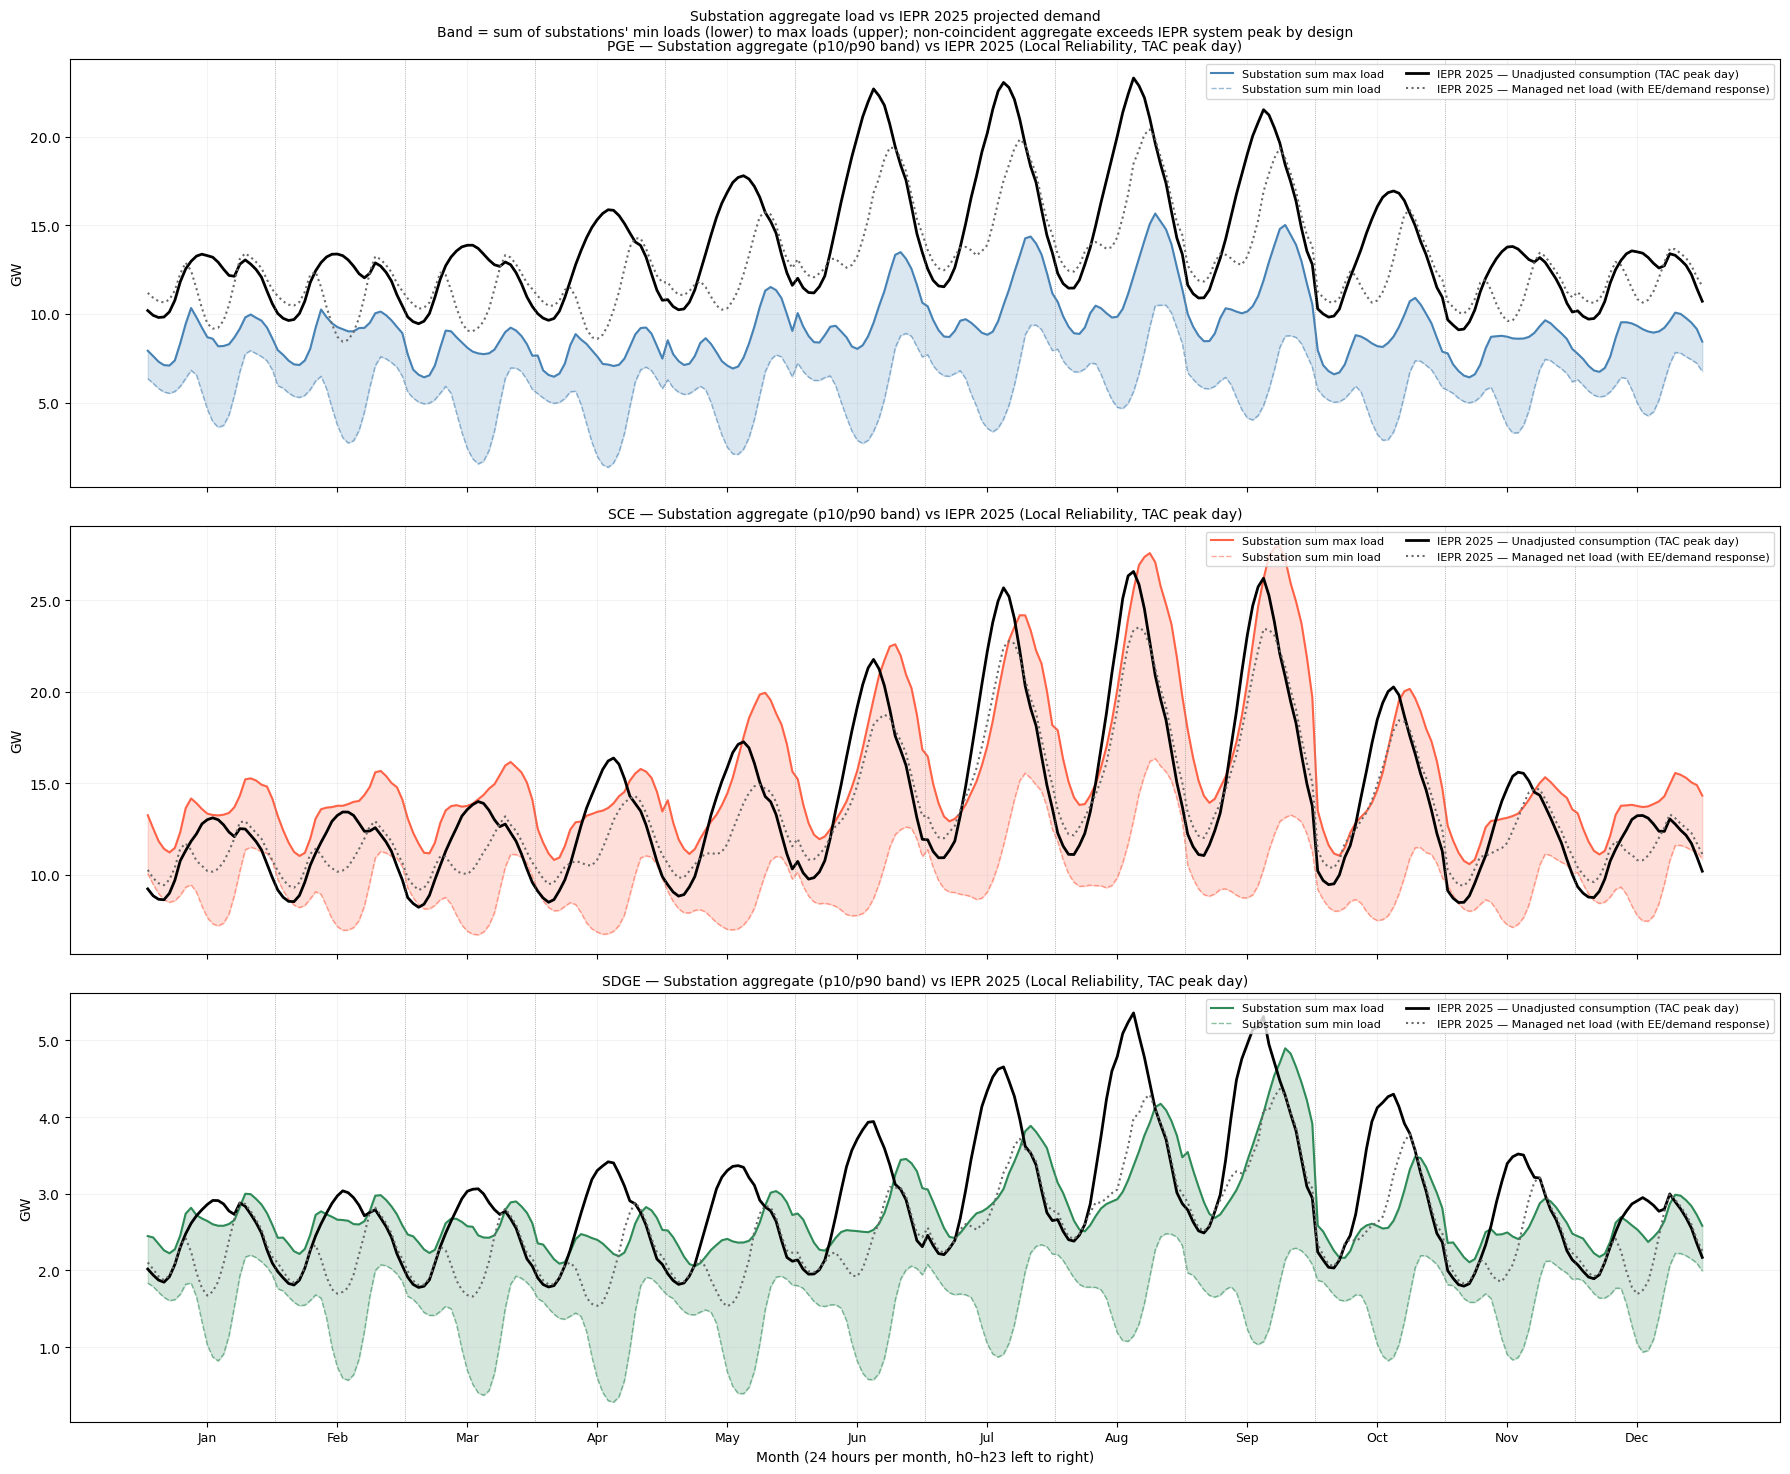

Peak month-hour comparison (substation aggregate max vs IEPR unadjusted):
Utility   Sub agg max (GW)  IEPR unadj (GW)   Ratio  Month  Hour
PGE                 15.66            19.63    0.80x      8    18
SCE                 27.98            22.08    1.27x      9    17
SDGE                 4.90             4.28    1.14x      9    18


In [113]:
# ── Load IEPR 2025 peak-day projections ──────────────────────────────────────
iepr_df = pd.read_csv(PROC / 'iepr' / 'iepr_monthly_peak_days.csv')

TAC_TO_UTIL = {'PGE': 'pge', 'SCE': 'sce', 'SDGE': 'sdge'}

# Local Reliability, year 2025, COINCIDENT=False → each TAC's own peak day
# (gives the highest load for that TAC per month; most comparable to substation max_load)
iepr_2025 = iepr_df[
    (iepr_df['YEAR'] == 2025) &
    (iepr_df['SCENARIO'] == 'Local_Reliability') &
    (iepr_df['TAC'].isin(TAC_TO_UTIL)) &
    (iepr_df['COINCIDENT'] == False)
][['TAC', 'MONTH', 'hour', 'UNADJUSTED_CONSUMPTION',
   'BASELINE_NET_LOAD', 'MANAGED_NET_LOAD']].copy()
iepr_2025['utility'] = iepr_2025['TAC'].map(TAC_TO_UTIL)
iepr_2025 = iepr_2025.rename(columns={'MONTH': 'month'})

# ── Substation aggregate bands ────────────────────────────────────────────────
# Guard for SDGE kW→MW (in case lp still has raw kW values)
lp_c = lp.copy()
if lp_c[lp_c.utility == 'sdge']['max_load'].max() > 1000:
    lp_c.loc[lp_c.utility == 'sdge', ['min_load', 'max_load']] /= 1000

agg_b = (
    lp_c[lp_c.utility.isin(IOU3)]
    .groupby(['utility', 'month', 'hour'])[['min_load', 'max_load']]
    .sum()
    .reset_index()
)

# Merge substation aggregate with IEPR projections
comp = agg_b.merge(
    iepr_2025[['utility', 'month', 'hour',
               'UNADJUSTED_CONSUMPTION', 'BASELINE_NET_LOAD', 'MANAGED_NET_LOAD']],
    on=['utility', 'month', 'hour'], how='left'
)

# Ordered 288 month-hour index for x-axis
month_hours = [(m, h) for m in range(1, 13) for h in range(24)]
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
mh_idx = {(m, h): i for i, (m, h) in enumerate(month_hours)}
comp['x'] = comp.apply(lambda r: mh_idx.get((int(r['month']), int(r['hour'])), np.nan), axis=1)

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(18, 15), sharex=True)

for ax, util in zip(axes, IOU3):
    d = comp[comp.utility == util].sort_values('x')
    x    = d['x'].values
    ymax = d['max_load'].values / 1000   # GW
    ymin = d['min_load'].values / 1000

    # Substation p10/p90 band
    ax.fill_between(x, ymin, ymax, alpha=0.20, color=UTIL_COLOR[util])
    ax.plot(x, ymax, color=UTIL_COLOR[util], lw=1.5,
            label='Substation sum max load')
    ax.plot(x, ymin, color=UTIL_COLOR[util], lw=1.0, ls='--', alpha=0.55,
            label='Substation sum min load')

    # IEPR 2025 overlays
    ax.plot(x, d['UNADJUSTED_CONSUMPTION'].values / 1000,
            'k-', lw=2.0, label='IEPR 2025 — Unadjusted consumption (TAC peak day)')
    ax.plot(x, d['MANAGED_NET_LOAD'].values / 1000,
            color='dimgray', lw=1.5, ls=':',
            label='IEPR 2025 — Managed net load (with EE/demand response)')

    # Month separators
    for mi in range(1, 12):
        ax.axvline(mi * 24 - 0.5, color='grey', lw=0.5, ls=':')

    ax.set_title(
        f'{util.upper()} — Substation aggregate (p10/p90 band) vs IEPR 2025 '
        f'(Local Reliability, TAC peak day)',
        fontsize=10
    )
    ax.set_ylabel('GW')
    ax.legend(fontsize=8, ncol=2, loc='upper right')
    ax.grid(True, alpha=0.15)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.1f}'))

axes[-1].set_xticks([m * 24 + 11 for m in range(12)])
axes[-1].set_xticklabels(month_names, fontsize=9)
axes[-1].set_xlabel('Month (24 hours per month, h0–h23 left to right)')

plt.suptitle(
    'Substation aggregate load vs IEPR 2025 projected demand\n'
    'Band = sum of substations\' min loads (lower) to max loads (upper); '
    'non-coincident aggregate exceeds IEPR system peak by design',
    fontsize=10
)
plt.tight_layout()
plt.show()

# ── Key comparison table ──────────────────────────────────────────────────────
print('Peak month-hour comparison (substation aggregate max vs IEPR unadjusted):')
print(f'{"Utility":6s}  {"Sub agg max (GW)":>17s}  {"IEPR unadj (GW)":>15s}  '
      f'{"Ratio":>6s}  {"Month":>5s}  {"Hour":>4s}')
for util in IOU3:
    d = comp[comp.utility == util].dropna(subset=['UNADJUSTED_CONSUMPTION'])
    if d.empty:
        continue
    i_pk = d['max_load'].idxmax()
    row  = d.loc[i_pk]
    ratio = row['max_load'] / row['UNADJUSTED_CONSUMPTION']
    print(f'{util.upper():6s}  {row["max_load"]/1000:>17.2f}  '
          f'{row["UNADJUSTED_CONSUMPTION"]/1000:>15.2f}  '
          f'{ratio:>6.2f}x  {int(row.month):>5d}  {int(row.hour):>4d}')

---
## Section 3 — Load vs Generation Capacity Ratios

For each IOU utility, compare the aggregate substation peak load against the
existing DER/generation capacity.  The ratio `sum(max_load) / sum(existing_gen)`
shows how much DER generation has been built relative to peak demand.  Ratios
well above 1 indicate demand far exceeds local DER; ratios approaching 1 indicate
high DER penetration relative to peak.

In [87]:
# Total existing and total gen capacity per utility
gen_summary = (
    loc[loc.utility.isin(IOU3)]
    .groupby('utility')[['existing_gen', 'queued_gen', 'total_gen', 'projected_load']]
    .agg(lambda x: x[x > 0].sum())
    .round(1)
)
print('Generation capacity by utility (MW, excluding zeros):')
print(gen_summary.to_string())

# Peak aggregate load (max across all months/hours)
peak_agg = agg.groupby('utility')['max_load'].max()
print()
print('Peak aggregate substation max_load (MW, sum across all substations):')
print(peak_agg.to_string())
print()
print('Note: substation peaks are not coincident — actual system peak is lower than this sum.')

Generation capacity by utility (MW, excluding zeros):
         existing_gen  queued_gen  total_gen  projected_load
utility                                                     
pge            3625.1      4725.7     8350.8             0.0
sce            8187.8      2311.5    10499.3         23300.4
sdge           3362.8       258.0     3620.8          4997.3

Peak aggregate substation max_load (MW, sum across all substations):
utility
pge     15657.73400
sce     27982.59000
sdge     4896.45394

Note: substation peaks are not coincident — actual system peak is lower than this sum.


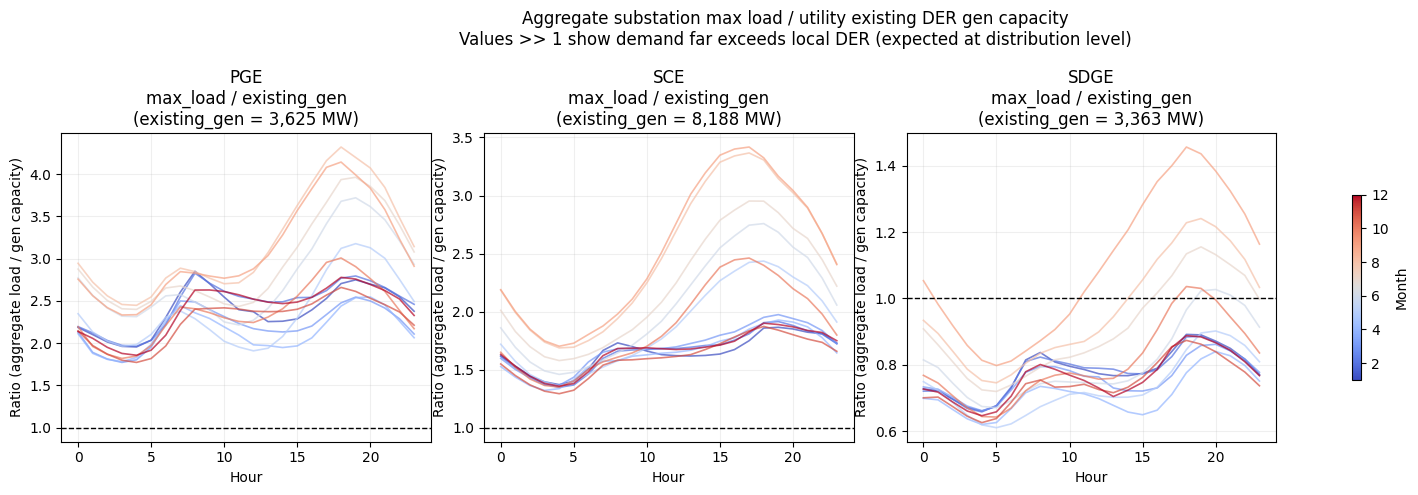

In [88]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)

for ax, util in zip(axes, IOU3):
    existing = gen_summary.loc[util, 'existing_gen'] if util in gen_summary.index else 0
    total    = gen_summary.loc[util, 'total_gen']    if util in gen_summary.index else 0
    d = agg[agg.utility == util]

    # One line per month
    cmap = plt.cm.coolwarm
    for m in range(1, 13):
        row = d[d.month == m].sort_values('hour')
        if existing > 0:
            ratio = row['max_load'] / existing
            ax.plot(row.hour, ratio, color=cmap((m-1)/11), alpha=0.7, lw=1.2, label=f'Mo {m}')

    if existing > 0:
        ax.axhline(1, color='black', lw=1, ls='--', label='ratio=1 (load = existing gen)')
    ax.set_title(f'{util.upper()}\nmax_load / existing_gen\n(existing_gen = {existing:,.0f} MW)')
    ax.set_xlabel('Hour')
    ax.set_ylabel('Ratio (aggregate load / gen capacity)')
    ax.grid(True, alpha=0.2)

# Shared colorbar for months
sm = plt.cm.ScalarMappable(cmap=plt.cm.coolwarm, norm=mcolors.Normalize(1, 12))
sm.set_array([])
plt.suptitle('Aggregate substation max load / utility existing DER gen capacity\n'
             'Values >> 1 show demand far exceeds local DER (expected at distribution level)')
plt.tight_layout()
fig.colorbar(sm, ax=axes, label='Month', shrink=0.6)
plt.show()

---
## Section 4 — EIA Regional Time Series

Hourly demand, net generation, and total interchange for each of the 8 California
balancing authorities and the CAL aggregate.  Monthly averages are plotted to reduce
noise; the raw hourly series is used for the interchange analysis in Section 5.

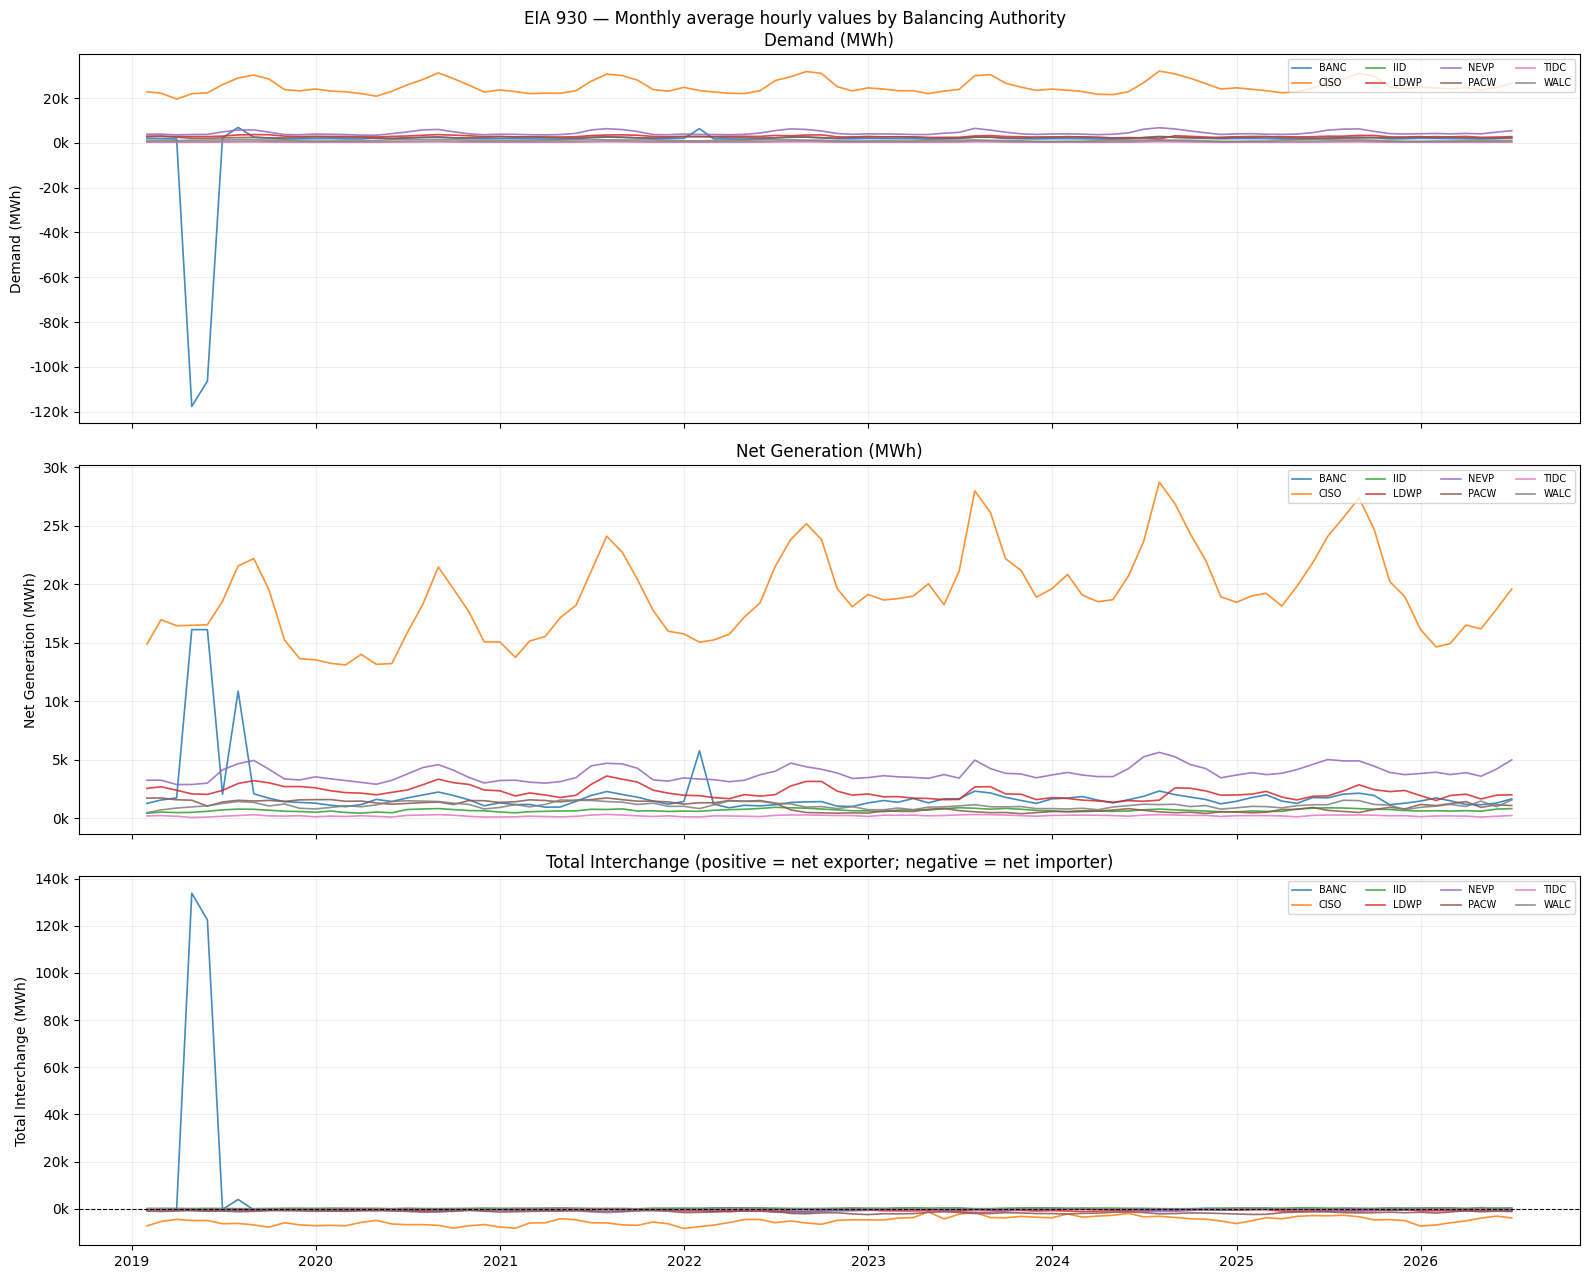

In [89]:
# Monthly averages per BA
reg_monthly = (
    reg[reg.respondent != 'CAL']
    .groupby(['respondent', pd.Grouper(key='dt', freq='ME')])
    [['demand', 'net_gen', 'total_interchange']]
    .mean()
    .reset_index()
)

fig, axes = plt.subplots(3, 1, figsize=(16, 13), sharex=True)
labels = {'demand': 'Demand (MWh)', 'net_gen': 'Net Generation (MWh)', 'total_interchange': 'Total Interchange (MWh)'}

for ax, col in zip(axes, ['demand', 'net_gen', 'total_interchange']):
    for ba in CA8:
        d = reg_monthly[reg_monthly.respondent == ba]
        ax.plot(d['dt'], d[col], label=ba, color=BA_COLOR[ba], lw=1.2, alpha=0.85)
    ax.set_ylabel(labels[col])
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
    ax.legend(ncol=4, fontsize=7, loc='upper right')
    ax.grid(True, alpha=0.2)
    if col == 'total_interchange':
        ax.axhline(0, color='black', lw=0.8, ls='--')
        ax.set_title('Total Interchange (positive = net exporter; negative = net importer)')
    else:
        ax.set_title(labels[col])

plt.suptitle('EIA 930 — Monthly average hourly values by Balancing Authority', fontsize=12)
plt.tight_layout()
plt.show()

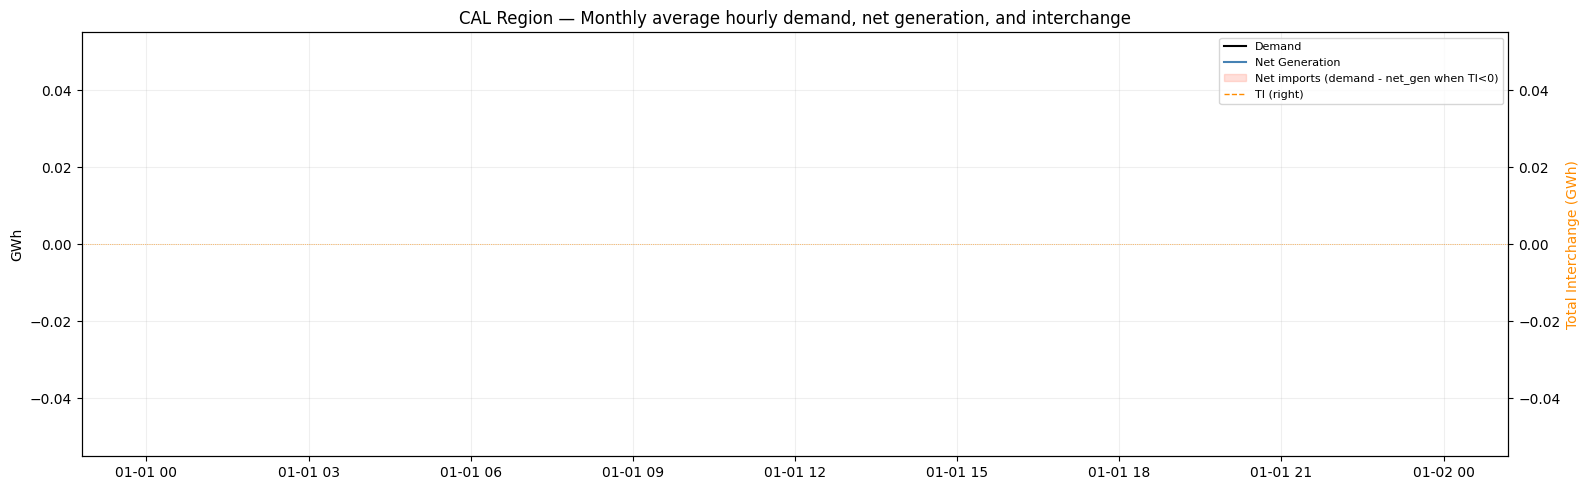

In [90]:
# CAL aggregate time series
cal = reg[reg.respondent == 'CAL'].copy()
cal_monthly = cal.groupby(pd.Grouper(key='dt', freq='ME'))[['demand','net_gen','total_interchange']].mean()
# cal_monthly = cal.set_index('dt')

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(cal_monthly.index, cal_monthly['demand']/1000,           label='Demand', color='black', lw=1.5)
ax.plot(cal_monthly.index, cal_monthly['net_gen']/1000,          label='Net Generation', color='steelblue', lw=1.5)
ax.fill_between(cal_monthly.index,
                (cal_monthly['demand'] + cal_monthly['total_interchange'])/1000,
                cal_monthly['demand']/1000,
                alpha=0.2, color='tomato', label='Net imports (demand - net_gen when TI<0)')
ax2 = ax.twinx()
ax2.plot(cal_monthly.index, cal_monthly['total_interchange']/1000, color='darkorange', lw=1, ls='--', label='TI (right)')
ax2.axhline(0, color='darkorange', lw=0.5, ls=':')
ax2.set_ylabel('Total Interchange (GWh)', color='darkorange')
ax.set_ylabel('GWh')
ax.set_title('CAL Region — Monthly average hourly demand, net generation, and interchange')
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=8)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

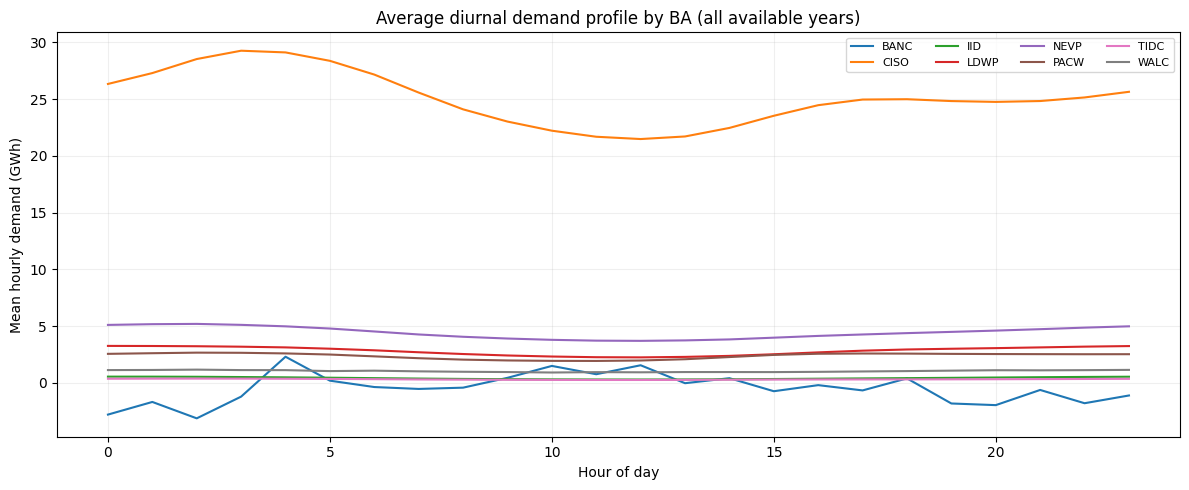

In [91]:
# Diurnal profile by BA: average demand by hour-of-day (all years)
diurnal = (
    reg[reg.respondent.isin(CA8)]
    .groupby(['respondent', 'hour'])['demand']
    .mean()
    .unstack('respondent')
)

fig, ax = plt.subplots(figsize=(12, 5))
for ba in CA8:
    if ba in diurnal.columns:
        ax.plot(diurnal.index, diurnal[ba]/1000, label=ba, color=BA_COLOR[ba], lw=1.5)
ax.set_xlabel('Hour of day')
ax.set_ylabel('Mean hourly demand (GWh)')
ax.set_title('Average diurnal demand profile by BA (all available years)')
ax.legend(ncol=4, fontsize=8)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

---
## Section 5 — Interchange Balance: Implied Generation and Import Swings

For each BA at each hour:
- **Net export** = sum of all interchange flows where `fromba` = that BA  
  (positive = net exporter, negative = net importer)
- **Implied generation** to meet demand = `demand + net_export`  
  (if exporting, must generate enough to cover own demand plus exports)

This should match `net_gen` from the region series; discrepancies reflect
measurement differences between the two EIA data products.

In [92]:
# Compute net interchange per BA per period from interchange data
# sum(value where fromba=BA) = BA's total net export to all counterparts
ic_net = (
    ic[ic.fromba.isin(CA8)]
    .groupby(['fromba', 'dt'])['value']
    .sum()
    .rename('ic_net_export')
    .reset_index()
    .rename(columns={'fromba': 'respondent'})
)
# Merge with region data
ba_reg = reg[reg.respondent.isin(CA8)][['respondent','dt','demand','net_gen','total_interchange']].copy()
ba_full = ba_reg.merge(ic_net, on=['respondent','dt'], how='left')
ba_full['implied_gen']  = ba_full['demand'] + ba_full['ic_net_export']  # gen must cover demand + exports
ba_full['gen_residual'] = ba_full['net_gen'] - ba_full['implied_gen']   # should be ~0 if TI matches

print('Residual (net_gen - implied_gen) by BA:')
print(
    ba_full.groupby('respondent')['gen_residual']
    .agg(['mean','std','min','max'])
    .round(1)
    .to_string()
)

Residual (net_gen - implied_gen) by BA:
             mean      std        min        max
respondent                                      
BANC        -30.4  20179.0 -3295175.0  3294880.0
CISO       -932.2   1815.7   -19215.0    16228.0
IID          -5.6     67.9    -1153.0     1035.0
LDWP          6.1    240.3    -3207.0     3795.0
NEVP         17.7    274.0    -4564.0     8928.0
PACW          9.6    431.3    -1240.0   105406.0
TIDC          0.1     21.4     -221.0      594.0
WALC          7.5     97.2     -837.0     2257.0


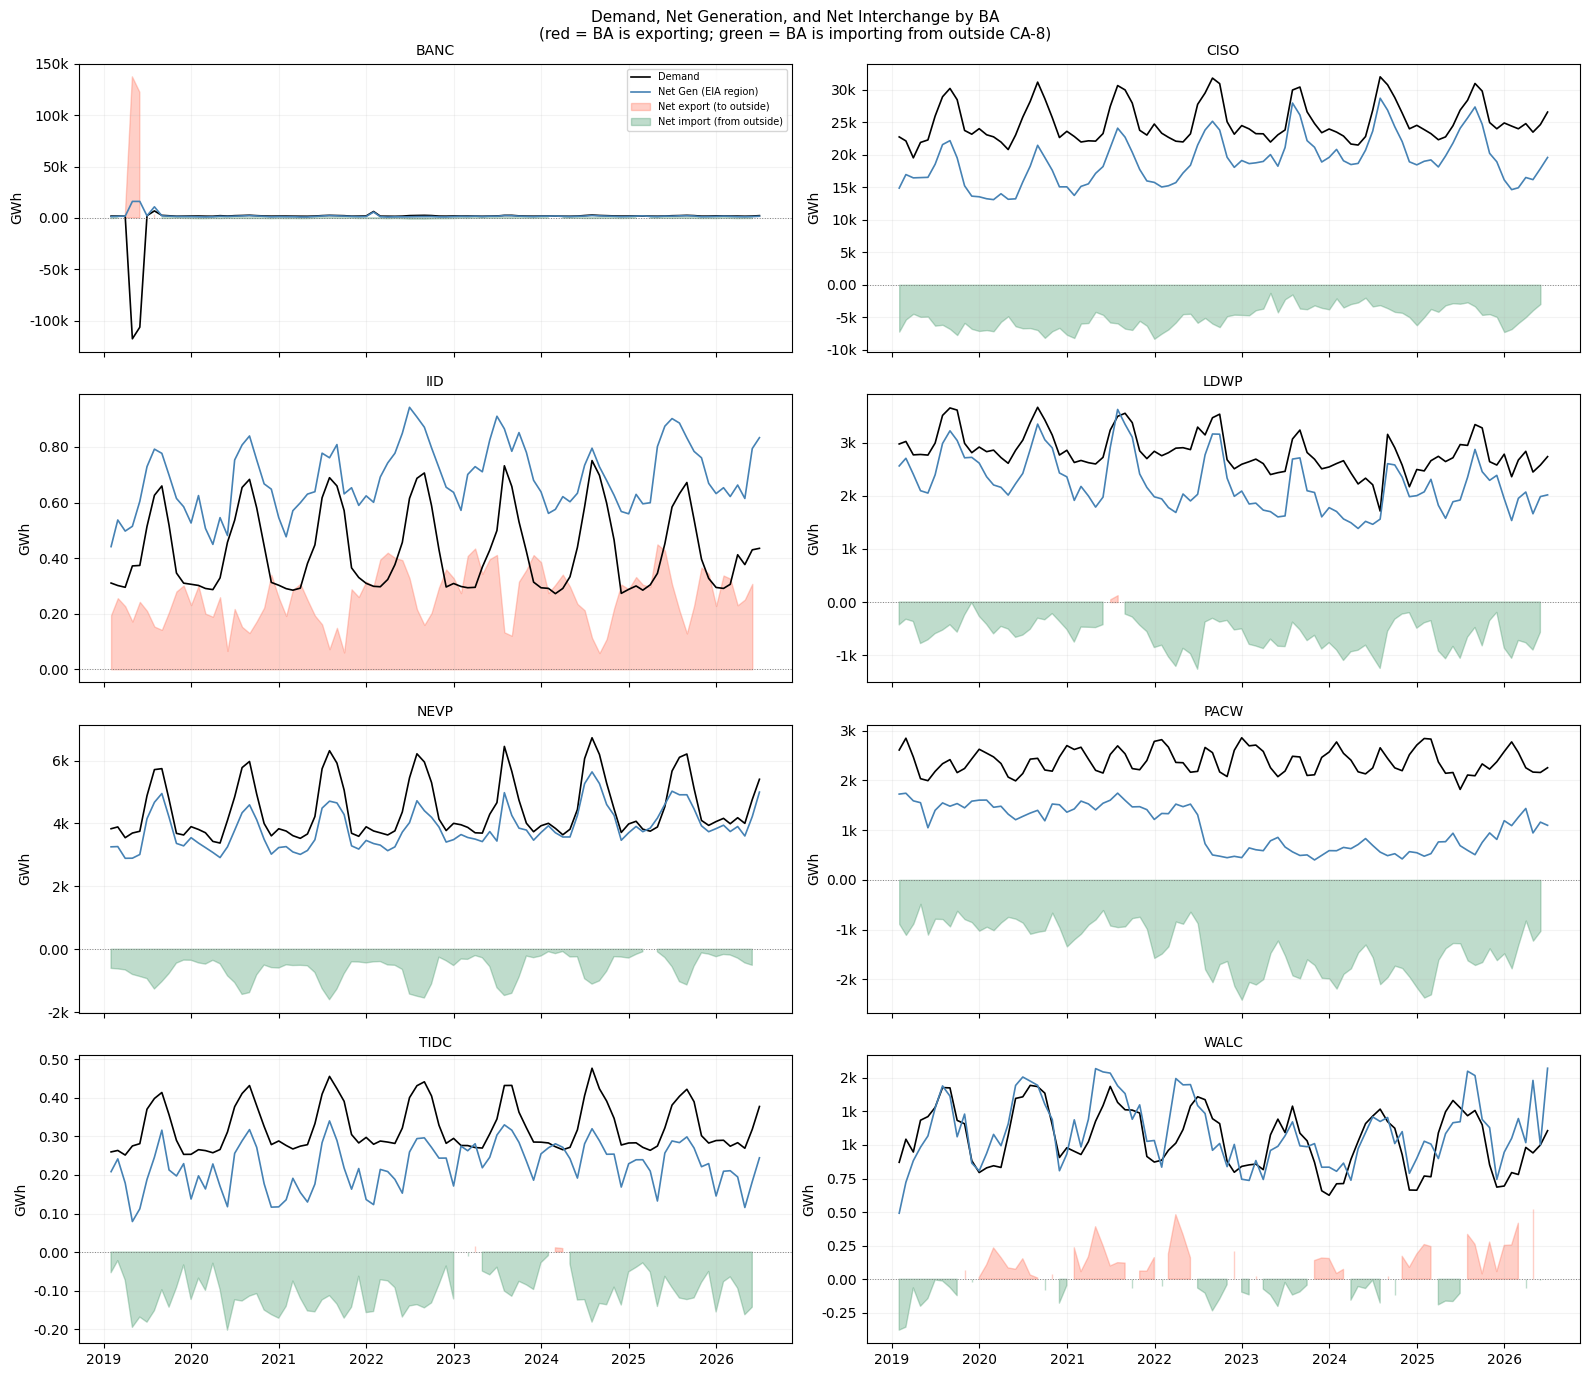

In [93]:
# Monthly net interchange swings by BA
ic_monthly = (
    ba_full
    .groupby(['respondent', pd.Grouper(key='dt', freq='ME')])
    [['demand','net_gen','ic_net_export']]
    .mean()
    .reset_index()
)

fig, axes = plt.subplots(4, 2, figsize=(16, 14), sharex=True)
axes_flat = axes.flatten()

for i, ba in enumerate(CA8):
    ax = axes_flat[i]
    d = ic_monthly[ic_monthly.respondent == ba]
    ax.plot(d['dt'], d['demand']/1000,        label='Demand', color='black', lw=1.2)
    ax.plot(d['dt'], d['net_gen']/1000,        label='Net Gen (EIA region)', color='steelblue', lw=1.2)
    ax.fill_between(d['dt'],
                    0, d['ic_net_export']/1000,
                    where=d['ic_net_export'] >= 0,
                    alpha=0.3, color='tomato', label='Net export (to outside)')
    ax.fill_between(d['dt'],
                    d['ic_net_export']/1000, 0,
                    where=d['ic_net_export'] < 0,
                    alpha=0.3, color='seagreen', label='Net import (from outside)')
    ax.axhline(0, color='grey', lw=0.7, ls=':')
    ax.set_title(f'{ba}', fontsize=10)
    ax.set_ylabel('GWh')
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}k' if abs(x) >= 1 else f'{x:.2f}'))
    ax.grid(True, alpha=0.15)
    if i == 0:
        ax.legend(fontsize=7, loc='upper right')

plt.suptitle('Demand, Net Generation, and Net Interchange by BA\n'
             '(red = BA is exporting; green = BA is importing from outside CA-8)', fontsize=11)
plt.tight_layout()
plt.show()

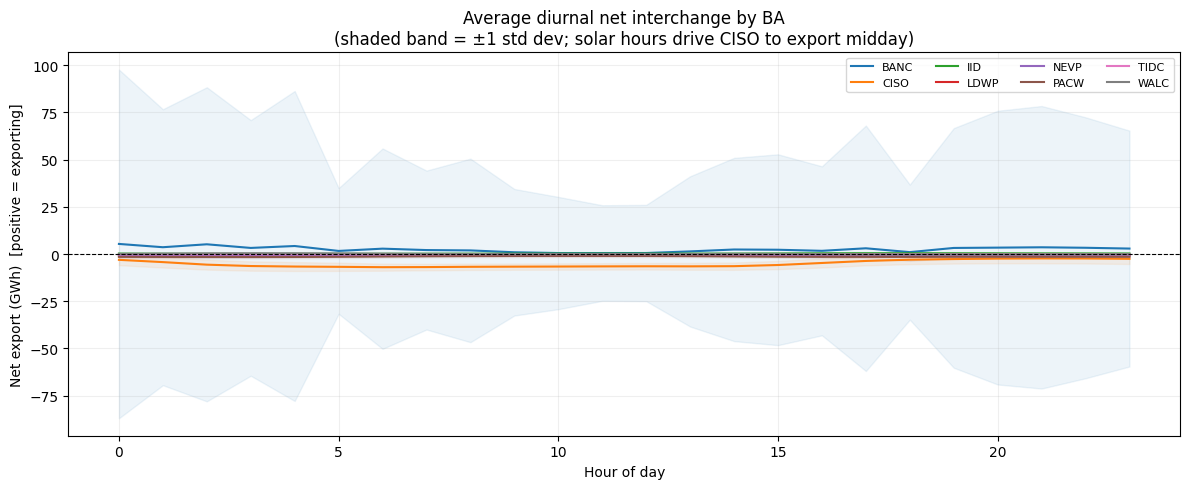

In [94]:
# Average diurnal swing in net interchange (how much does import/export vary by hour)
ba_full['hour'] = ba_full['dt'].dt.hour
ic_diurnal = (
    ba_full
    .groupby(['respondent', 'hour'])['ic_net_export']
    .agg(['mean','std'])
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 5))
for ba in CA8:
    d = ic_diurnal[ic_diurnal.respondent == ba]
    ax.plot(d.hour, d['mean']/1000, label=ba, color=BA_COLOR[ba], lw=1.5)
    ax.fill_between(d.hour, (d['mean']-d['std'])/1000, (d['mean']+d['std'])/1000,
                   alpha=0.08, color=BA_COLOR[ba])

ax.axhline(0, color='black', lw=0.8, ls='--')
ax.set_xlabel('Hour of day')
ax.set_ylabel('Net export (GWh)  [positive = exporting]')
ax.set_title('Average diurnal net interchange by BA\n(shaded band = ±1 std dev; solar hours drive CISO to export midday)')
ax.legend(ncol=4, fontsize=8)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

---
## Section 6 — Substation Aggregate vs EIA Demand: Non-Coincidence

The substation load profiles store the *peak* ever observed in each month/hour bin.
Summing these peaks across all substations produces a value much higher than the
actual system peak — because each substation's worst hour is different.

The ratio `Σ(substation peaks) / EIA demand` at each hour is the
**non-coincidence factor** for that hour.  A value of 2x means the sum of all
substation peaks is twice the actual system demand at that hour.

**Approximate BA mapping used:**  
- CISO ≈ PGE + SCE + SDGE combined (CISO is the primary BA for all three IOU territories)  
- The comparison is approximate — PGE also overlaps BANC, TIDC; some SCE territory overlaps IID/LDWP.

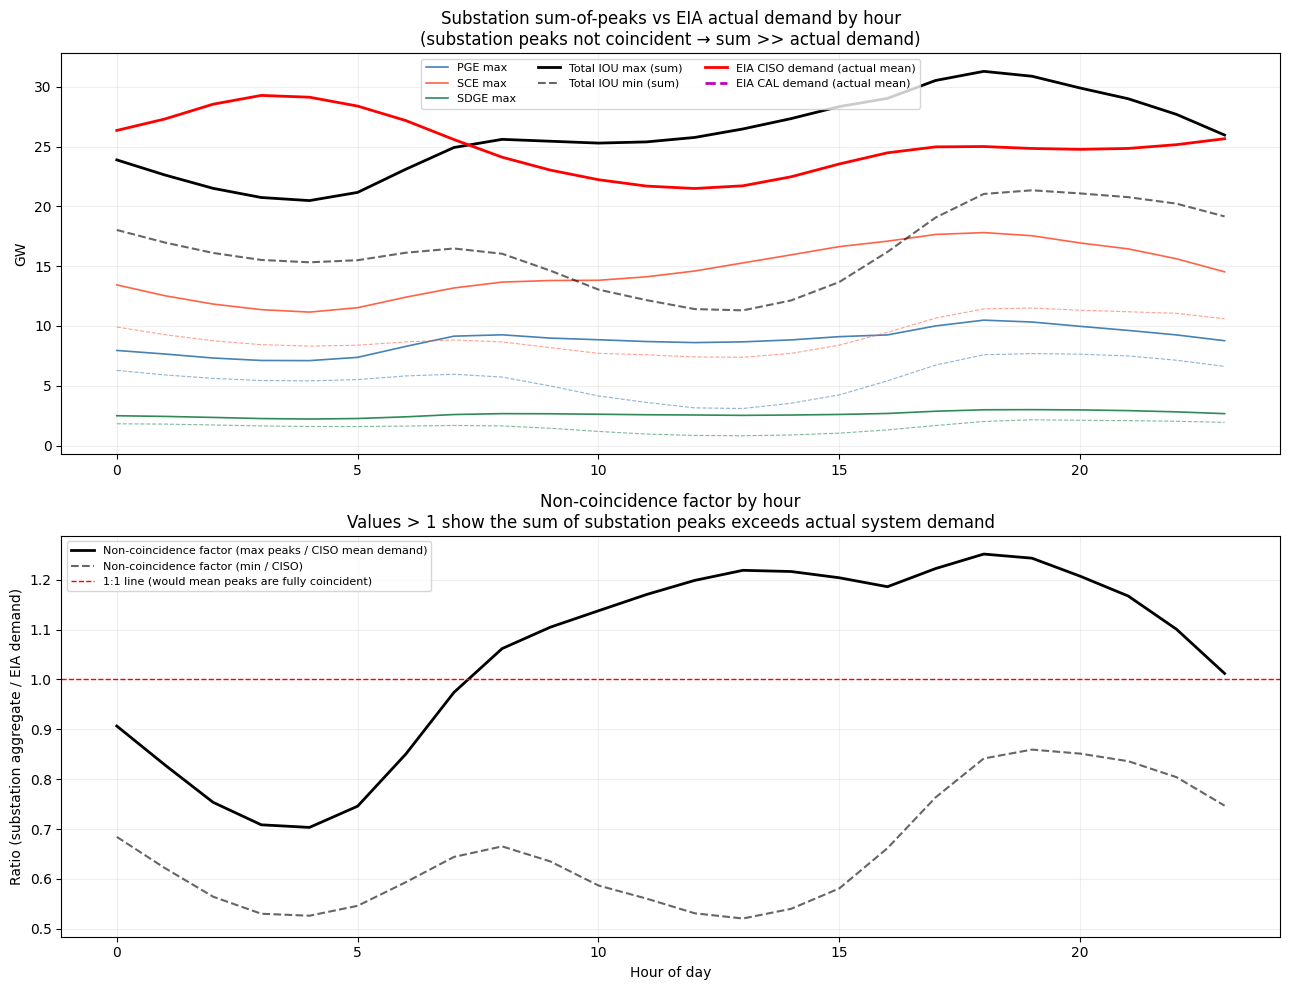


Peak non-coincidence factor (max_load): 1.25x at hour 18
Min non-coincidence factor (max_load): 0.70x at hour 4


In [95]:
# Substation aggregate by hour across all months (median across months for robustness)
sub_hourly = (
    lp[lp.utility.isin(IOU3)]
    .groupby(['utility','month','hour'])[['min_load','max_load']]
    .sum()
    .groupby(['utility','hour'])
    .median()  # median across months to get a representative hour profile
    .reset_index()
)
sub_total = sub_hourly.groupby('hour')[['min_load','max_load']].sum().reset_index()

# EIA CISO diurnal profile (mean by hour across all available data)
ciso_diurnal = reg[reg.respondent=='CISO'].groupby('hour')['demand'].mean()
cal_diurnal  = reg[reg.respondent=='CAL'].groupby('hour')['demand'].mean()

fig, axes = plt.subplots(2, 1, figsize=(13, 10))

# Top: raw comparison
ax = axes[0]
for util in IOU3:
    d = sub_hourly[sub_hourly.utility == util]
    ax.plot(d.hour, d.max_load/1000, label=f'{util.upper()} max', color=UTIL_COLOR[util], lw=1.2)
    ax.plot(d.hour, d.min_load/1000, color=UTIL_COLOR[util], lw=0.8, ls='--', alpha=0.6)
ax.plot(sub_total.hour, sub_total.max_load/1000, 'k-',  lw=2, label='Total IOU max (sum)')
ax.plot(sub_total.hour, sub_total.min_load/1000, 'k--', lw=1.5, alpha=0.6, label='Total IOU min (sum)')
ax.plot(ciso_diurnal.index, ciso_diurnal.values/1000, 'r-',  lw=2, label='EIA CISO demand (actual mean)')
ax.plot(cal_diurnal.index,  cal_diurnal.values/1000,  'm--', lw=2, label='EIA CAL demand (actual mean)')
ax.set_ylabel('GW')
ax.set_title('Substation sum-of-peaks vs EIA actual demand by hour\n'
             '(substation peaks not coincident → sum >> actual demand)')
ax.legend(fontsize=8, ncol=3)
ax.grid(True, alpha=0.2)

# Bottom: non-coincidence factor
ax = axes[1]
sub_total_idx = sub_total.set_index('hour')
noncoin_max = sub_total_idx['max_load'] / ciso_diurnal
noncoin_min = sub_total_idx['min_load'] / ciso_diurnal
ax.plot(noncoin_max.index, noncoin_max.values, 'k-',  lw=2, label='Non-coincidence factor (max peaks / CISO mean demand)')
ax.plot(noncoin_min.index, noncoin_min.values, 'k--', lw=1.5, alpha=0.6, label='Non-coincidence factor (min / CISO)')
ax.axhline(1, color='red', lw=1, ls='--', label='1:1 line (would mean peaks are fully coincident)')
ax.set_xlabel('Hour of day')
ax.set_ylabel('Ratio (substation aggregate / EIA demand)')
ax.set_title('Non-coincidence factor by hour\n'
             'Values > 1 show the sum of substation peaks exceeds actual system demand')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

print(f'\nPeak non-coincidence factor (max_load): {noncoin_max.max():.2f}x at hour {noncoin_max.idxmax()}')
print(f'Min non-coincidence factor (max_load): {noncoin_max.min():.2f}x at hour {noncoin_max.idxmin()}')

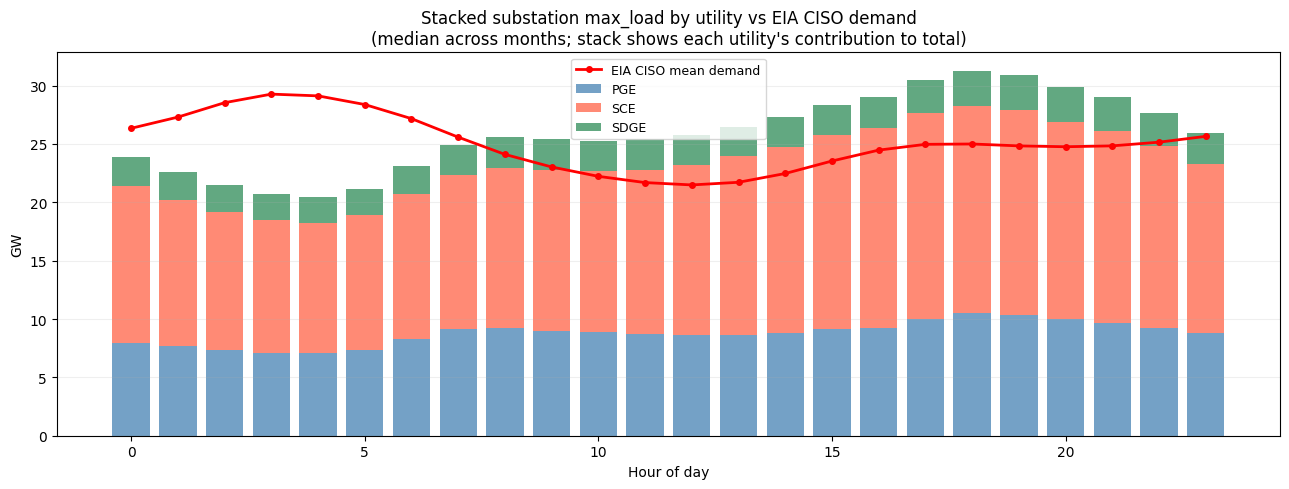

In [96]:
# Per-utility contribution to non-coincidence: show each utility's share of the aggregate
fig, ax = plt.subplots(figsize=(13, 5))
bottom = np.zeros(24)
for util in IOU3:
    d = sub_hourly[sub_hourly.utility == util].set_index('hour')['max_load'] / 1000
    ax.bar(d.index, d.values, bottom=bottom, label=util.upper(),
           color=UTIL_COLOR[util], alpha=0.75, width=0.8)
    bottom += d.values

ax.plot(ciso_diurnal.index, ciso_diurnal.values/1000, 'r-o', lw=2, ms=4,
       label='EIA CISO mean demand')
ax.set_xlabel('Hour of day')
ax.set_ylabel('GW')
ax.set_title('Stacked substation max_load by utility vs EIA CISO demand\n'
             '(median across months; stack shows each utility\'s contribution to total)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.2, axis='y')
plt.tight_layout()
plt.show()

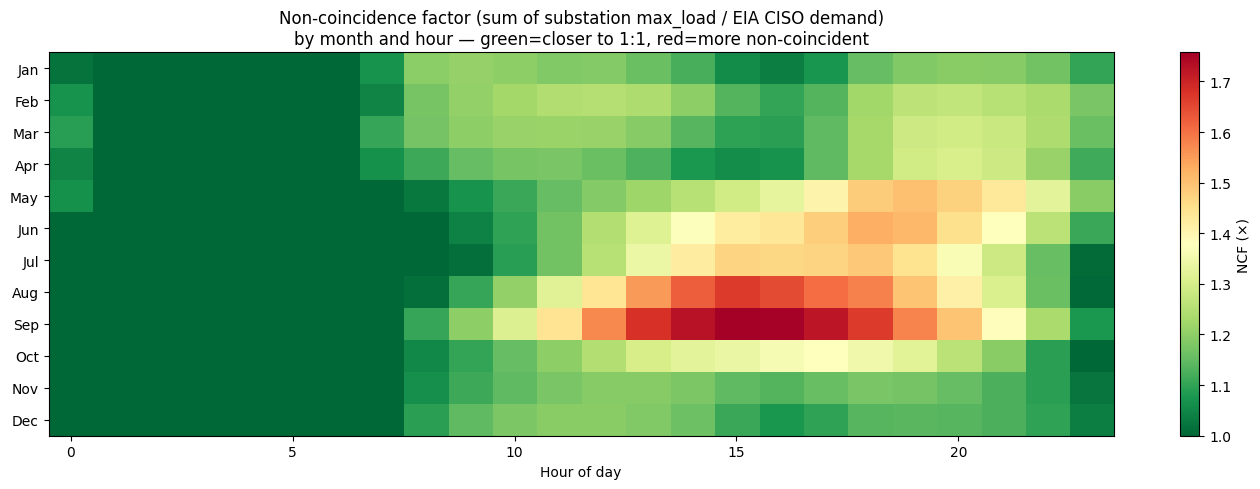

In [97]:
# Seasonal variation in non-coincidence factor
sub_monthly_hourly = (
    lp[lp.utility.isin(IOU3)]
    .groupby(['month','hour'])[['min_load','max_load']]
    .sum()
    .reset_index()
)
ciso_monthly_hourly = (
    reg[reg.respondent=='CISO']
    .groupby(['month','hour'])['demand']
    .mean()
    .reset_index()
)
ncf = sub_monthly_hourly.merge(ciso_monthly_hourly, on=['month','hour'])
ncf['ncf'] = ncf['max_load'] / ncf['demand']

ncf_pivot = ncf.pivot(index='month', columns='hour', values='ncf')
fig, ax = plt.subplots(figsize=(14, 5))
im = ax.imshow(ncf_pivot, aspect='auto', cmap='RdYlGn_r', vmin=1, vmax=ncf_pivot.values.max())
ax.set_yticks(range(12))
ax.set_yticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
ax.set_xlabel('Hour of day')
ax.set_title('Non-coincidence factor (sum of substation max_load / EIA CISO demand)\n'
             'by month and hour — green=closer to 1:1, red=more non-coincident')
plt.colorbar(im, label='NCF (×)', ax=ax)
plt.tight_layout()
plt.show()

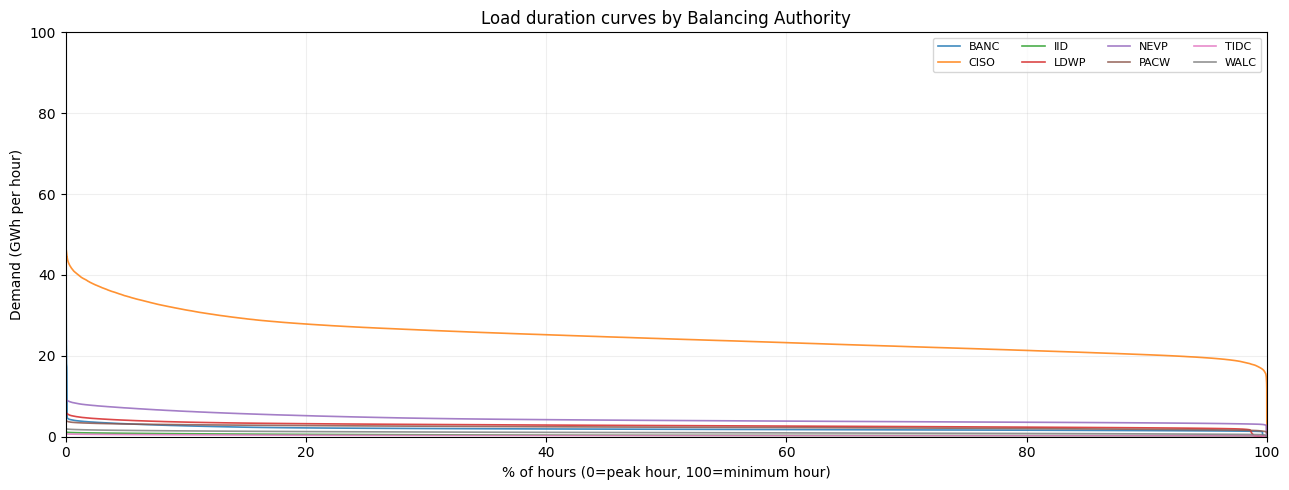

In [98]:
#Load duration curves by BA
fig, ax = plt.subplots(figsize=(13, 5))

for ba in CA8:
    demand_sorted = reg[reg.respondent==ba]['demand'].dropna().sort_values(ascending=False).values
    if len(demand_sorted) == 0:
        continue
    pct = np.linspace(0, 100, len(demand_sorted))
    ax.plot(pct, demand_sorted/1000, label=ba, color=BA_COLOR[ba], lw=1.2, alpha=0.85)

ax.set_xlabel('% of hours (0=peak hour, 100=minimum hour)')
ax.set_ylabel('Demand (GWh per hour)')
ax.set_title('Load duration curves by Balancing Authority')
ax.legend(ncol=4, fontsize=8)
ax.grid(True, alpha=0.2)
ax.set_xlim(0, 100)
ax.set_ylim(0,100)
plt.tight_layout()
plt.show()

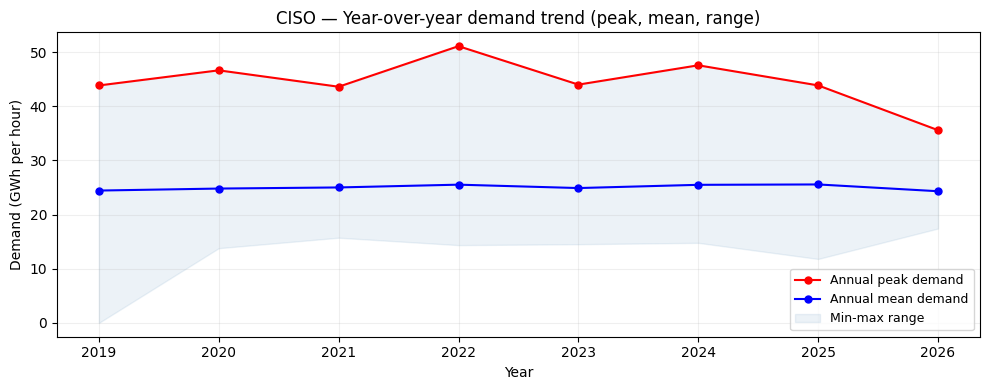

CISO annual summary (GWh/hr):
      annual_peak  annual_mean  annual_min
year                                      
2019        43.85        24.45        0.01
2020        46.64        24.81       13.81
2021        43.62        25.02       15.74
2022        51.10        25.53       14.37
2023        44.01        24.91       14.54
2024        47.57        25.50       14.79
2025        43.86        25.57       11.82
2026        35.60        24.32       17.44


In [99]:
#Year-over-year CISO peak demand trend
ciso_annual = (
    reg[reg.respondent=='CISO']
    .groupby('year')['demand']
    .agg(annual_peak='max', annual_mean='mean', annual_min='min')
)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(ciso_annual.index, ciso_annual['annual_peak']/1000, 'r-o', lw=1.5, ms=5, label='Annual peak demand')
ax.plot(ciso_annual.index, ciso_annual['annual_mean']/1000, 'b-o', lw=1.5, ms=5, label='Annual mean demand')
ax.fill_between(ciso_annual.index,
                ciso_annual['annual_min']/1000,
                ciso_annual['annual_peak']/1000,
                alpha=0.1, color='steelblue', label='Min-max range')
ax.set_xlabel('Year')
ax.set_ylabel('Demand (GWh per hour)')
ax.set_title('CISO — Year-over-year demand trend (peak, mean, range)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

print('CISO annual summary (GWh/hr):')
print((ciso_annual/1000).round(2).to_string())

---
## Section 7 — Substation Generation Capacity Histogram

Distribution of `existing_gen` (MW) across all substations by utility.
Substations at zero or with no data are counted separately in the title.

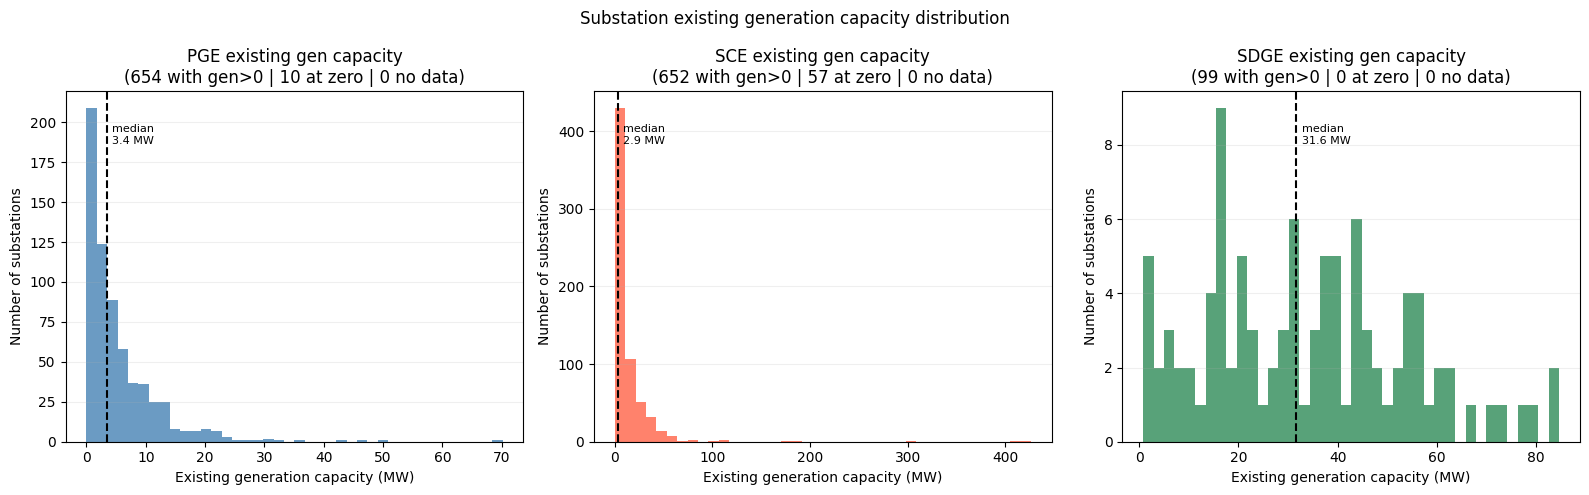

Summary (substations with gen > 0):
  PGE   : n=654  min=0.00  p25=1.17  median=3.41  p75=7.22  max=70.14  total=3625 MW
  SCE   : n=652  min=0.00  p25=0.54  median=2.92  p75=16.34  max=426.24  total=8188 MW
  SDGE  : n= 99  min=0.82  p25=17.47  median=31.65  p75=47.11  max=84.66  total=3363 MW


In [100]:
loc2 = pd.read_csv(PROC / 'substations' / 'substation_locations.csv', low_memory=False)
for c in ['existing_gen', 'total_gen', 'queued_gen']:
    loc2[c] = pd.to_numeric(loc2[c], errors='coerce')

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, util in zip(axes, IOU3):
    all_gen  = loc2[loc2.utility == util]['existing_gen']
    n_zero   = (all_gen.fillna(0) == 0).sum()
    n_miss   = all_gen.isna().sum()
    pos      = all_gen[all_gen > 0].dropna()

    ax.hist(pos, bins=40, color=UTIL_COLOR[util], edgecolor='none', alpha=0.8)
    ax.set_title(
        f'{util.upper()} existing gen capacity\n'
        f'({len(pos)} with gen>0 | {int(n_zero)-int(n_miss)} at zero | {int(n_miss)} no data)'
    )
    ax.set_xlabel('Existing generation capacity (MW)')
    ax.set_ylabel('Number of substations')
    if len(pos):
        med = pos.median()
        ax.axvline(med, color='black', lw=1.5, ls='--')
        ax.annotate(f'median\n{med:.1f} MW', xy=(med, ax.get_ylim()[1] * 0.85),
                    xytext=(4, 0), textcoords='offset points', fontsize=8)
    ax.grid(True, alpha=0.2, axis='y')

plt.suptitle('Substation existing generation capacity distribution')
plt.tight_layout()
plt.show()

print('Summary (substations with gen > 0):')
for util in IOU3:
    pos = loc2[loc2.utility==util]['existing_gen']
    pos = pos[pos > 0].dropna()
    print(f'  {util.upper():6s}: n={len(pos):3d}  '
          f'min={pos.min():.2f}  p25={pos.quantile(.25):.2f}  '
          f'median={pos.median():.2f}  p75={pos.quantile(.75):.2f}  '
          f'max={pos.max():.2f}  total={pos.sum():.0f} MW')

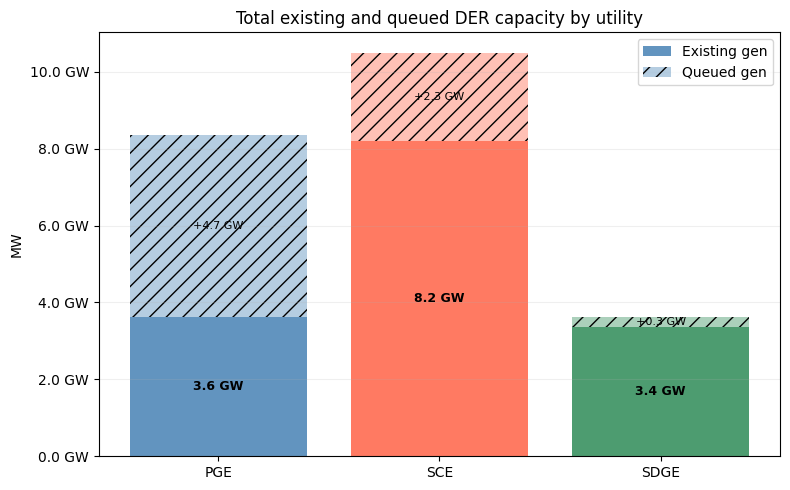

In [101]:
# Stacked bar: existing vs queued capacity totals by utility
fig, ax = plt.subplots(figsize=(8, 5))
x = list(range(len(IOU3)))
existing_totals = [loc2[loc2.utility==u]['existing_gen'].fillna(0).clip(lower=0).sum() for u in IOU3]
queued_totals   = [loc2[loc2.utility==u]['queued_gen'].fillna(0).clip(lower=0).sum() for u in IOU3]

ax.bar(x, existing_totals, color=[UTIL_COLOR[u] for u in IOU3], alpha=0.85, label='Existing gen')
ax.bar(x, queued_totals, bottom=existing_totals,
       color=[UTIL_COLOR[u] for u in IOU3], alpha=0.4, hatch='//', label='Queued gen')
ax.set_xticks(x)
ax.set_xticklabels([u.upper() for u in IOU3])
ax.set_ylabel('MW')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v/1000:.1f} GW'))
ax.set_title('Total existing and queued DER capacity by utility')
ax.legend()
ax.grid(True, alpha=0.2, axis='y')
for i, (e, q) in enumerate(zip(existing_totals, queued_totals)):
    ax.text(i, e/2, f'{e/1000:.1f} GW', ha='center', va='center', fontsize=9, fontweight='bold')
    if q > 0:
        ax.text(i, e + q/2, f'+{q/1000:.1f} GW', ha='center', va='center', fontsize=8)
plt.tight_layout()
plt.show()

---
## Section 8 — Load Duration Curves by Year

For each year with complete data, aggregate all substation `max_load` across every
substation, repeat each (month, hour) value by the number of days in that month
(yielding 8 760 data points for a standard non-leap year), and sort descending.
One line per year on the same plot makes year-over-year changes visible.

Only **SCE** has annual labels.  PGE and SDGE profiles carry no year information,
so they produce a single representative curve shown in a companion panel.

SCE complete years: [2017, 2018, 2022, 2023, 2024, 2025]


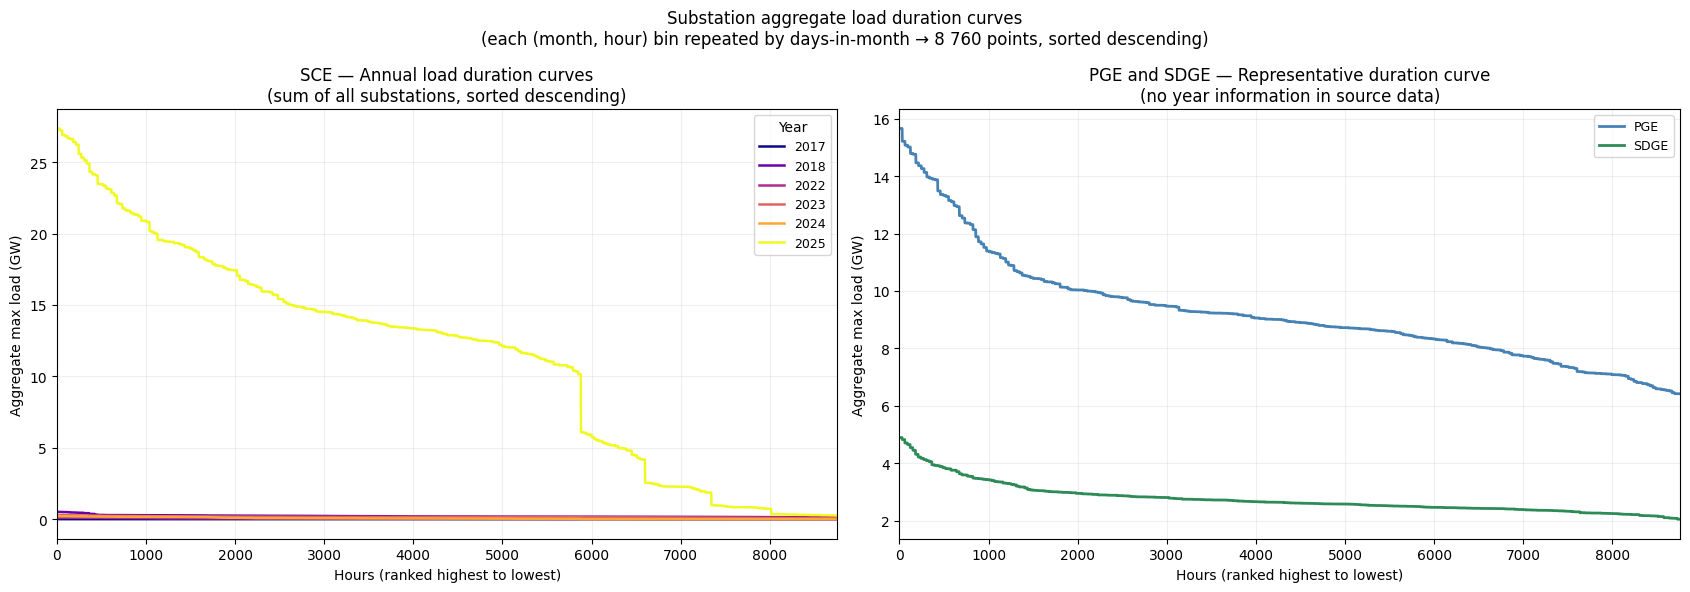

In [102]:
DAYS_PER_MONTH = {1:31, 2:28, 3:31, 4:30, 5:31, 6:30,
                  7:31, 8:31, 9:30, 10:31, 11:30, 12:31}

def make_duration_curve(df_slice):
    """Aggregate by (month,hour), expand to 8760 hours, return sorted-desc array."""
    agg = df_slice.groupby(['month', 'hour'])['max_load'].sum()
    values = []
    for m, days in DAYS_PER_MONTH.items():
        for h in range(24):
            val = agg.get((m, h), np.nan)
            values.extend([val] * days)
    arr = np.array(values, dtype=float)
    return np.sort(arr[~np.isnan(arr)])[::-1]

# Use the load profiles already in memory (lp with SDGE corrected)
# Guard for sessions where lp still has uncorrected SDGE
lp_dc = lp.copy()
if lp_dc[lp_dc.utility=='sdge']['max_load'].max() > 1000:
    lp_dc.loc[lp_dc.utility=='sdge', ['min_load','max_load']] /= 1000

sce_lp = lp_dc[lp_dc.utility == 'sce'].copy()
complete_years = sorted(
    y for y in sce_lp['year'].dropna().unique()
    if sce_lp[sce_lp.year == y]['month'].nunique() == 12
)
print(f'SCE complete years: {[int(y) for y in complete_years]}')

cmap_yr = plt.cm.plasma
n_yrs   = len(complete_years)

fig, axes = plt.subplots(1, 2, figsize=(17, 6))

# ── Left panel: SCE by year ───────────────────────────────────────────────
ax = axes[0]
for i, yr in enumerate(complete_years):
    dc = make_duration_curve(sce_lp[sce_lp.year == yr])
    x  = np.linspace(0, 8760, len(dc))
    ax.plot(x, dc / 1000,
            color=cmap_yr(i / max(n_yrs - 1, 1)),
            lw=1.8, label=str(int(yr)))
ax.set_xlabel('Hours (ranked highest to lowest)')
ax.set_ylabel('Aggregate max load (GW)')
ax.set_title('SCE — Annual load duration curves\n'
             '(sum of all substations, sorted descending)')
ax.legend(title='Year', fontsize=9)
ax.grid(True, alpha=0.2)
ax.set_xlim(0, 8760)

# ── Right panel: PGE and SDGE ────────────────────────────────────────────
ax = axes[1]
for util, color in [('pge', 'steelblue'), ('sdge', 'seagreen')]:
    dc = make_duration_curve(lp_dc[lp_dc.utility == util])
    x  = np.linspace(0, 8760, len(dc))
    ax.plot(x, dc / 1000, color=color, lw=2.0, label=util.upper())
ax.set_xlabel('Hours (ranked highest to lowest)')
ax.set_ylabel('Aggregate max load (GW)')
ax.set_title('PGE and SDGE — Representative duration curve\n'
             '(no year information in source data)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.2)
ax.set_xlim(0, 8760)

plt.suptitle(
    'Substation aggregate load duration curves\n'
    '(each (month, hour) bin repeated by days-in-month → 8 760 points, sorted descending)'
)
plt.tight_layout()
plt.show()

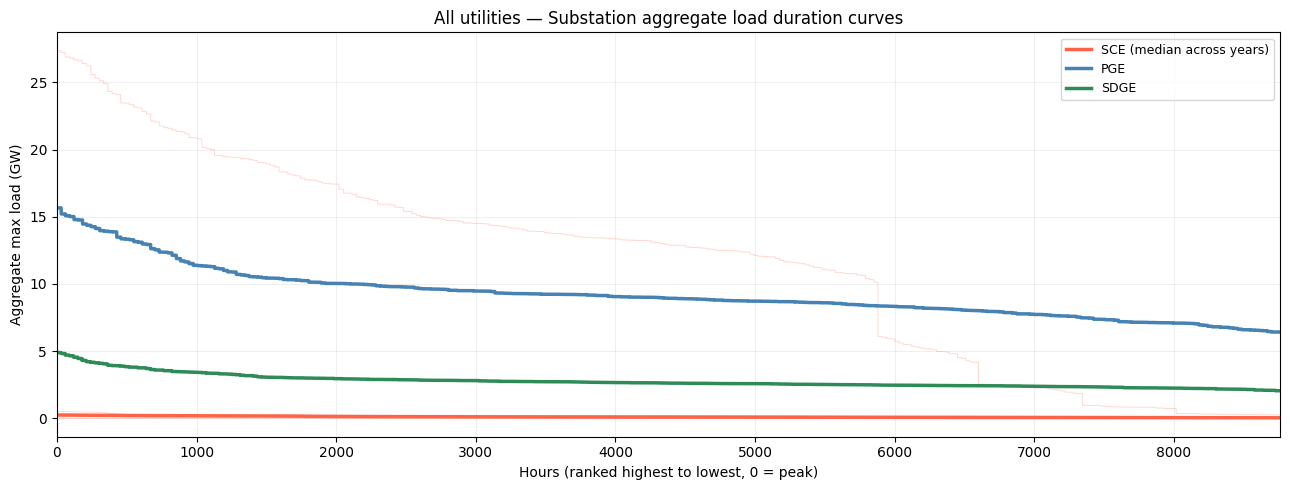

Duration curve statistics:
  PGE   : peak=15.66 GW  base=6.42 GW  load_factor=0.41
  SDGE  : peak=4.90 GW  base=2.05 GW  load_factor=0.42
  SCE 2017: peak=0.00 GW  base=0.00 GW  load_factor=0.42
  SCE 2018: peak=0.51 GW  base=0.13 GW  load_factor=0.25
  SCE 2022: peak=0.11 GW  base=0.01 GW  load_factor=0.05
  SCE 2023: peak=0.29 GW  base=0.08 GW  load_factor=0.26
  SCE 2024: peak=0.21 GW  base=0.00 GW  load_factor=0.01
  SCE 2025: peak=27.35 GW  base=0.26 GW  load_factor=0.01


In [103]:
# All utilities on one plot — SCE shown per-year (thin) + median (thick)
fig, ax = plt.subplots(figsize=(13, 5))

sce_curves = []
for yr in complete_years:
    dc = make_duration_curve(sce_lp[sce_lp.year == yr])
    sce_curves.append(dc)
    x = np.linspace(0, 8760, len(dc))
    ax.plot(x, dc / 1000, color=UTIL_COLOR['sce'], lw=0.7, alpha=0.25)

if sce_curves:
    max_len    = max(len(c) for c in sce_curves)
    padded     = np.array([
        np.interp(np.linspace(0, 1, max_len), np.linspace(0, 1, len(c)), c)
        for c in sce_curves
    ])
    sce_median = np.median(padded, axis=0)
    ax.plot(np.linspace(0, 8760, max_len), sce_median / 1000,
            color=UTIL_COLOR['sce'], lw=2.5, label='SCE (median across years)')

for util in ['pge', 'sdge']:
    dc = make_duration_curve(lp_dc[lp_dc.utility == util])
    ax.plot(np.linspace(0, 8760, len(dc)), dc / 1000,
            color=UTIL_COLOR[util], lw=2.5, label=f'{util.upper()}')

ax.set_xlabel('Hours (ranked highest to lowest, 0 = peak)')
ax.set_ylabel('Aggregate max load (GW)')
ax.set_title('All utilities — Substation aggregate load duration curves')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.2)
ax.set_xlim(0, 8760)
plt.tight_layout()
plt.show()

print('Duration curve statistics:')
for util in ['pge', 'sdge']:
    dc = make_duration_curve(lp_dc[lp_dc.utility == util])
    print(f'  {util.upper():6s}: peak={dc[0]/1000:.2f} GW  '
          f'base={dc[-1]/1000:.2f} GW  load_factor={dc[-1]/dc[0]:.2f}')
for yr in complete_years:
    dc = make_duration_curve(sce_lp[sce_lp.year == yr])
    print(f'  SCE {int(yr)}: peak={dc[0]/1000:.2f} GW  '
          f'base={dc[-1]/1000:.2f} GW  load_factor={dc[-1]/dc[0]:.2f}')

---
## Duck Curve and Growing BTM Solar (IEPR)

The IEPR peak-day forecast decomposes load into pre-BTM consumption (`BASELINE_CONSUMPTION`)
and post-BTM net load (`BASELINE_NET_LOAD`).  The difference is rooftop solar and storage.
Plotting both curves for the July peak day shows the classic duck curve shape, and
comparing 2024 → 2030 → 2040 shows how the midday trough deepens as BTM solar grows.

Source: `data/processed/iepr/iepr_monthly_peak_days.csv`, TAC=CAISO, SCENARIO=Local_Reliability.

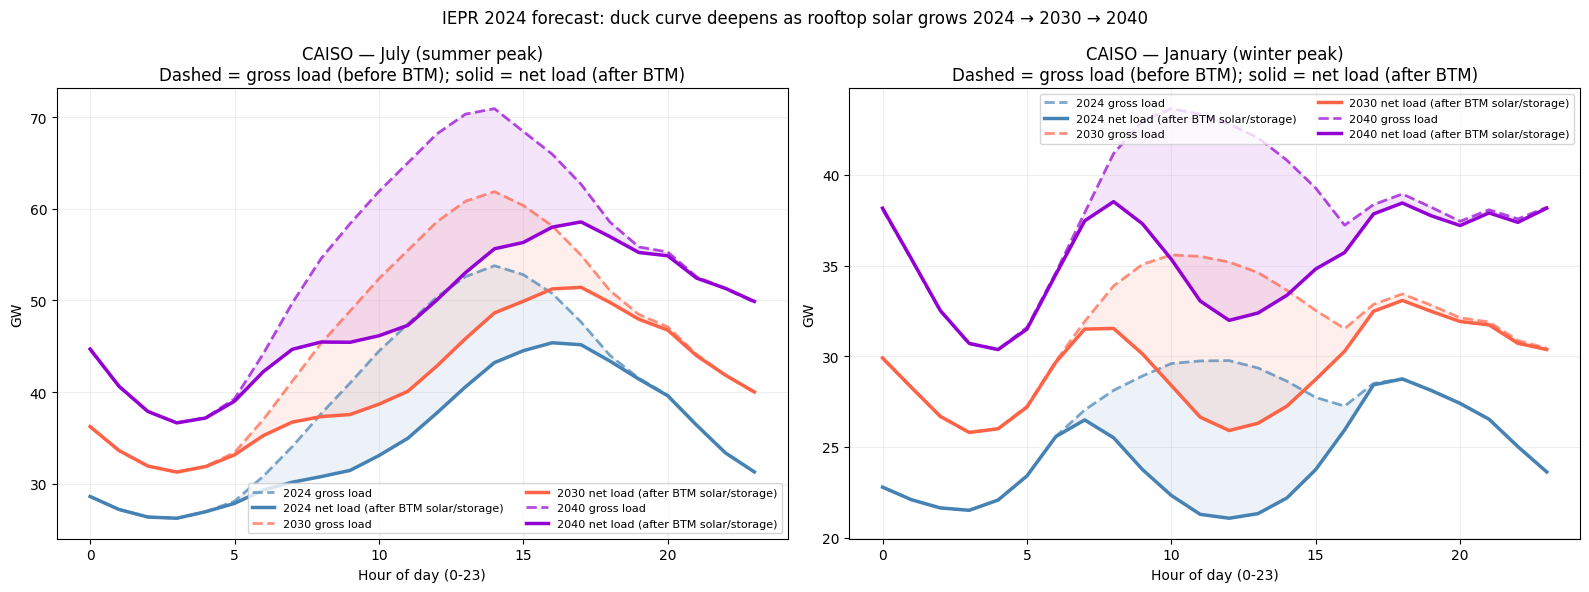

In [104]:
iepr = pd.read_csv(PROC / 'iepr' / 'iepr_monthly_peak_days.csv')
caiso = iepr[
    (iepr.TAC == 'CAISO') &
    (iepr.COINCIDENT == True) &
    (iepr.SCENARIO == 'Local_Reliability')
].copy()

highlight_years = [2024, 2030, 2040]
months_labels   = {7: 'July (summer peak)', 1: 'January (winter peak)'}
yr_colors = {2024: 'steelblue', 2030: 'tomato', 2040: 'darkviolet'}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (month, title) in zip(axes, months_labels.items()):
    for yr in highlight_years:
        row = caiso[(caiso.YEAR == yr) & (caiso.MONTH == month)].sort_values('hour')
        if row.empty:
            continue
        c = yr_colors[yr]
        ax.plot(row.hour, row.BASELINE_CONSUMPTION / 1000,
                color=c, lw=2, ls='--', alpha=0.7, label=f'{yr} gross load')
        ax.plot(row.hour, row.BASELINE_NET_LOAD / 1000,
                color=c, lw=2.5, label=f'{yr} net load (after BTM solar/storage)')
        ax.fill_between(
            row.hour,
            row.BASELINE_NET_LOAD / 1000,
            row.BASELINE_CONSUMPTION / 1000,
            alpha=0.10, color=c
        )
    ax.set_xlabel('Hour of day (0-23)')
    ax.set_ylabel('GW')
    ax.set_title(f'CAISO — {title}\n'
                 f'Dashed = gross load (before BTM); solid = net load (after BTM)')
    ax.legend(fontsize=8, ncol=2)
    ax.grid(True, alpha=0.2)

plt.suptitle('IEPR 2024 forecast: duck curve deepens as rooftop solar grows 2024 → 2030 → 2040')
plt.tight_layout()
plt.show()

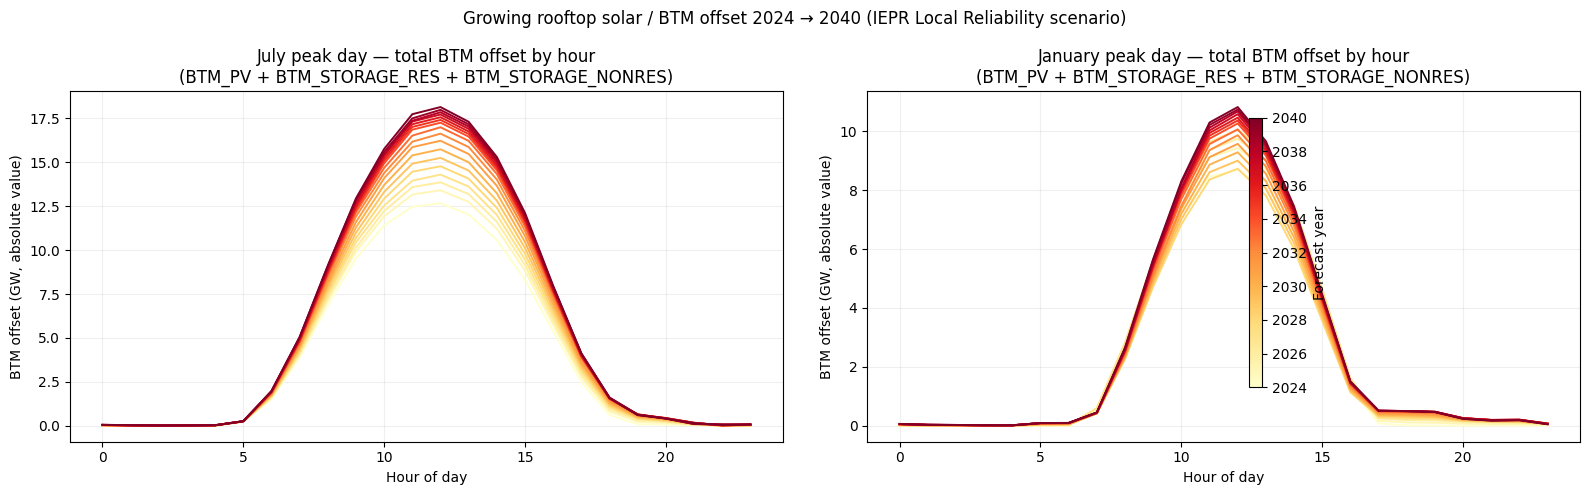

Peak BTM offset (July, GW):
YEAR
2024    12.69
2025    13.47
2026    13.95
2027    14.43
2028    14.90
2029    15.40
2030    15.91
2031    16.42
2032    16.86
2033    17.24
2034    17.48
2035    17.63
2036    17.79
2037    17.94
2038    18.10
2039    18.24
2040    18.37


In [105]:
# BTM solar (BTM_PV) by hour for every forecast year — shows ramp of rooftop solar
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
all_years = sorted(caiso.YEAR.unique())
cmap_yr = plt.cm.YlOrRd

for ax, month in zip(axes, [7, 1]):
    for i, yr in enumerate(all_years):
        row = caiso[(caiso.YEAR == yr) & (caiso.MONTH == month)].sort_values('hour')
        if row.empty:
            continue
        col = cmap_yr(i / max(len(all_years) - 1, 1))
        btm = row.BTM_PV + row.BTM_STORAGE_RES + row.BTM_STORAGE_NONRES
        ax.plot(row.hour, btm.abs() / 1000, color=col, lw=1.4, label=str(yr))
    ax.set_xlabel('Hour of day')
    ax.set_ylabel('BTM offset (GW, absolute value)')
    mname = 'July' if month == 7 else 'January'
    ax.set_title(f'{mname} peak day — total BTM offset by hour\n'
                 f'(BTM_PV + BTM_STORAGE_RES + BTM_STORAGE_NONRES)')
    ax.grid(True, alpha=0.2)

# Shared colorbar for years
sm = plt.cm.ScalarMappable(cmap=cmap_yr, norm=mcolors.Normalize(all_years[0], all_years[-1]))
sm.set_array([])
fig.colorbar(sm, ax=axes, label='Forecast year', shrink=0.7)
plt.suptitle('Growing rooftop solar / BTM offset 2024 → 2040 (IEPR Local Reliability scenario)')
plt.tight_layout()
plt.show()

# Peak BTM offset per year (July midday)
peak_btm = (
    caiso[caiso.MONTH == 7]
    .assign(btm_total=caiso.BTM_PV.abs() + caiso.BTM_STORAGE_RES.abs() + caiso.BTM_STORAGE_NONRES.abs())
    .groupby('YEAR')['btm_total'].max()
)
print('Peak BTM offset (July, GW):')
print((peak_btm / 1000).round(2).to_string())

---
## SCE Substation Coverage Gap

SCE's ICA Tables (Table 3) contain attribute data for 1,220 substations.  The DRPEP
bulk download (our load source) covers only 709 of them.  The remaining 511 are
present in the ICA planning data but have no published hourly load profiles.

Their combined `projected_load` is 17,018 MW — meaning our dataset currently covers
only **57.8%** of SCE's total planned peak capacity.  Comparing the aggregate of
covered substations' projected loads against the aggregate of uncovered substations
shows which parts of the system are invisible to us.

Substations with load data  :  709   projected_load = 23,298 MW
Substations WITHOUT load data:  511   projected_load = 17,018 MW
Coverage fraction (by projected_load): 57.8%



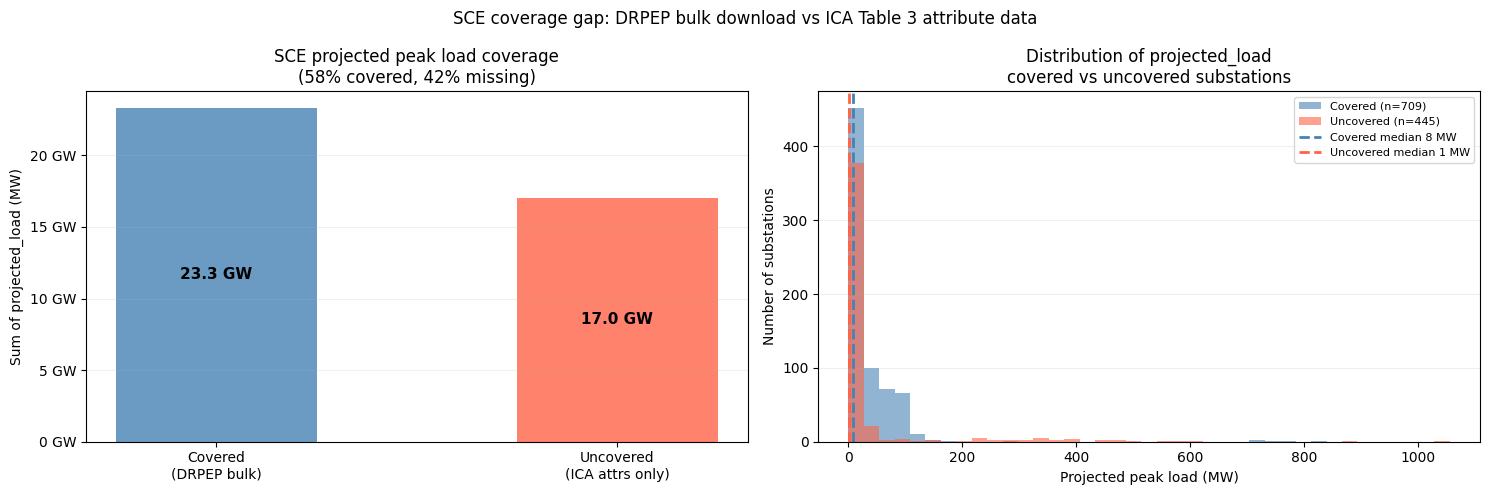

In [106]:
sce_attrs = pd.read_csv(
    ROOT / 'data' / 'raw' / 'sce' / 'sce_substation_attributes.csv'
)
sce_load_raw = pd.read_csv(
    ROOT / 'data' / 'raw' / 'sce' / 'sce_bulk_download_all.csv',
    usecols=['SUBSTATION']
)
load_subs = set(sce_load_raw.SUBSTATION.str.upper())
sce_attrs['has_load'] = sce_attrs.substation_name.str.upper().isin(load_subs)
for c in ['existing_gen','queued_gen','total_gen','projected_load']:
    sce_attrs[c] = pd.to_numeric(sce_attrs[c], errors='coerce')

covered   = sce_attrs[sce_attrs.has_load]
uncovered = sce_attrs[~sce_attrs.has_load]

cov_proj   = covered.projected_load.dropna().sum()
uncov_proj = uncovered.projected_load.dropna().sum()
total_proj = cov_proj + uncov_proj
print(f'Substations with load data  : {len(covered):4d}   projected_load = {cov_proj:,.0f} MW')
print(f'Substations WITHOUT load data: {len(uncovered):4d}   projected_load = {uncov_proj:,.0f} MW')
print(f'Coverage fraction (by projected_load): {cov_proj/total_proj:.1%}')
print()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Left: stacked bar of projected_load totals
ax = axes[0]
bars = ax.bar(['Covered\n(DRPEP bulk)', 'Uncovered\n(ICA attrs only)'],
              [cov_proj, uncov_proj],
              color=['steelblue', 'tomato'], alpha=0.8, width=0.5)
ax.set_ylabel('Sum of projected_load (MW)')
ax.set_title('SCE projected peak load coverage\n'
             f'({cov_proj/total_proj:.0%} covered, {uncov_proj/total_proj:.0%} missing)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{v/1000:.0f} GW'))
for bar, val in zip(bars, [cov_proj, uncov_proj]):
    ax.text(bar.get_x() + bar.get_width()/2, val/2,
            f'{val/1000:.1f} GW', ha='center', va='center', fontsize=11, fontweight='bold')
ax.grid(True, alpha=0.2, axis='y')

# Right: distribution of projected_load for uncovered substations
ax = axes[1]
proj_cov   = covered.projected_load.dropna()
proj_uncov = uncovered.projected_load.dropna()
bins = np.linspace(0, max(proj_cov.max(), proj_uncov.max()), 40)
ax.hist(proj_cov,   bins=bins, alpha=0.6, color='steelblue', label=f'Covered (n={len(proj_cov)})')
ax.hist(proj_uncov, bins=bins, alpha=0.6, color='tomato',    label=f'Uncovered (n={len(proj_uncov)})')
ax.axvline(proj_cov.median(),   color='steelblue', lw=2, ls='--', label=f'Covered median {proj_cov.median():.0f} MW')
ax.axvline(proj_uncov.median(), color='tomato',    lw=2, ls='--', label=f'Uncovered median {proj_uncov.median():.0f} MW')
ax.set_xlabel('Projected peak load (MW)')
ax.set_ylabel('Number of substations')
ax.set_title('Distribution of projected_load\ncovered vs uncovered substations')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.2, axis='y')

plt.suptitle('SCE coverage gap: DRPEP bulk download vs ICA Table 3 attribute data')
plt.tight_layout()
plt.show()

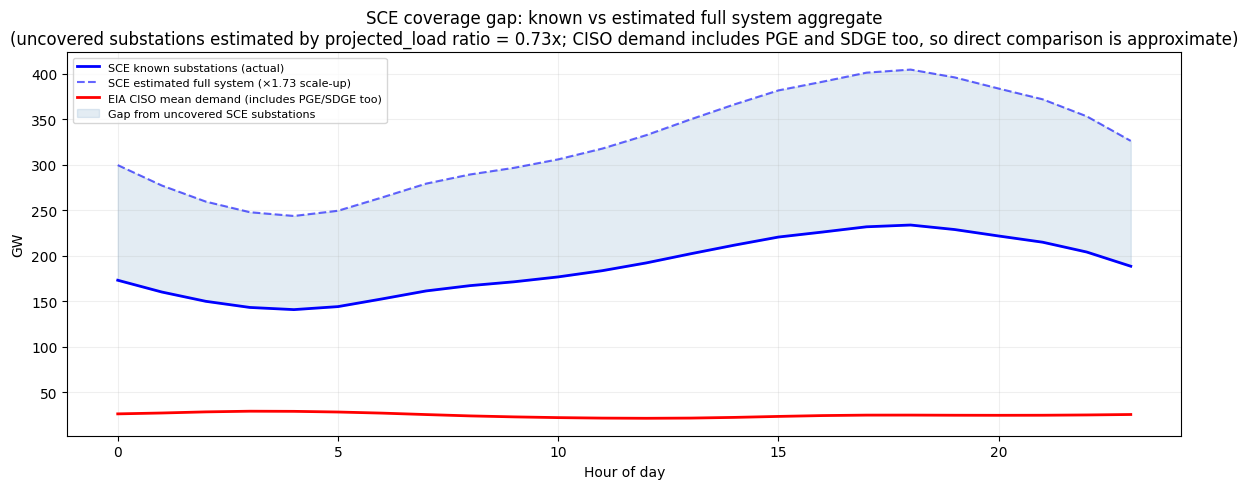

Scale factor applied: 0.73x   (uncov_proj 17018 / cov_proj 23298)
SCE current peak aggregate: 233.8 GW
SCE estimated full system:  404.6 GW


In [107]:
# Show how the coverage gap affects the non-coincidence factor calculation
# If we had load profiles for uncovered substations (at their projected_load),
# what would the aggregate look like?
sce_agg_current = (
    lp[lp.utility == 'sce']
    .groupby('hour')['max_load']
    .sum()
    .groupby('hour').median()
)  # median across months to get a representative profile

# Guard for SDGE unit issue
if lp[lp.utility=='sdge']['max_load'].max() > 1000:
    lp_sdge_scale = 1000
else:
    lp_sdge_scale = 1

ciso_diurnal2 = reg[reg.respondent == 'CISO'].groupby('hour')['demand'].mean()

# Estimate uncovered load: assume same diurnal shape as covered, scaled by ratio of projected_loads
scale_factor  = uncov_proj / cov_proj  # rough capacity scaling
sce_estimated_total = sce_agg_current * (1 + scale_factor)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(sce_agg_current.index,    sce_agg_current / 1000,    'b-',  lw=2,   label='SCE known substations (actual)')
ax.plot(sce_estimated_total.index, sce_estimated_total / 1000, 'b--', lw=1.5, alpha=0.6,
        label=f'SCE estimated full system (×{1+scale_factor:.2f} scale-up)')
ax.plot(ciso_diurnal2.index, ciso_diurnal2 / 1000, 'r-', lw=2,
        label='EIA CISO mean demand (includes PGE/SDGE too)')
ax.fill_between(sce_agg_current.index,
                sce_agg_current / 1000,
                sce_estimated_total / 1000,
                alpha=0.15, color='steelblue', label='Gap from uncovered SCE substations')
ax.set_xlabel('Hour of day')
ax.set_ylabel('GW')
ax.set_title('SCE coverage gap: known vs estimated full system aggregate\n'
             f'(uncovered substations estimated by projected_load ratio = {scale_factor:.2f}x; '
             f'CISO demand includes PGE and SDGE too, so direct comparison is approximate)')
ax.legend(fontsize=8)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

print(f'Scale factor applied: {scale_factor:.2f}x   (uncov_proj {uncov_proj:.0f} / cov_proj {cov_proj:.0f})')
print(f'SCE current peak aggregate: {sce_agg_current.max()/1000:.1f} GW')
print(f'SCE estimated full system:  {sce_estimated_total.max()/1000:.1f} GW')

---
## Interchange vs Net Generation Residual (Detailed)

Section 5 showed that `net_gen` (from the EIA region series) should equal
`demand + ic_net_export` (demand plus net interchange computed from the
interchange dataset).  The residual `net_gen − implied_gen` captures
everything the two products disagree on:

- Missing counterpart flows not in the interchange dataset
- Measurement timing differences
- Known data errors (BANC reported 3.3 TW to CISO on 2019-07-25 — genuine outlier)

**BANC outliers** from the 2019-07-25 data error (±3.3M MWh) are clipped at ±10,000 MWh
for all visualizations below.

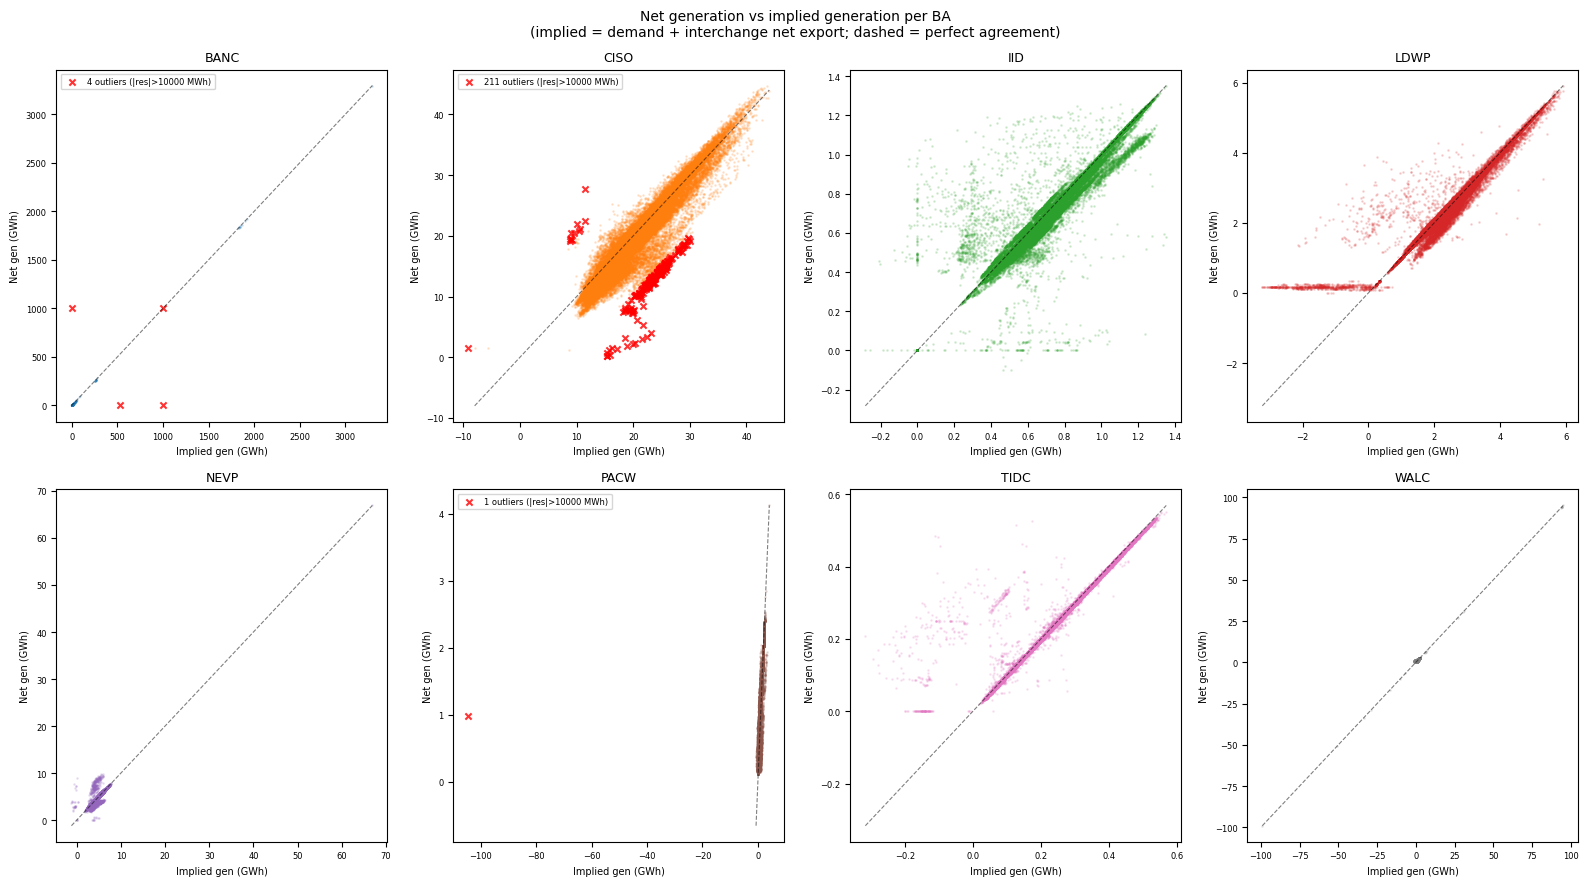

In [108]:
# Recompute ba_full (may already exist from Section 5 — recompute to be safe)
ic_net2 = (
    ic[ic.fromba.isin(CA8)]
    .groupby(['fromba', 'dt'])['value']
    .sum()
    .rename('ic_net_export')
    .reset_index()
    .rename(columns={'fromba': 'respondent'})
)
ba_reg2 = reg[reg.respondent.isin(CA8)][
    ['respondent', 'dt', 'demand', 'net_gen', 'total_interchange']
].copy()
bf = ba_reg2.merge(ic_net2, on=['respondent', 'dt'], how='left')
bf['implied_gen']  = bf['demand']  + bf['ic_net_export']
bf['gen_residual'] = bf['net_gen'] - bf['implied_gen']
CLIP = 10_000  # MWh — clip extreme BANC outliers for display
bf['residual_clipped'] = bf['gen_residual'].clip(-CLIP, CLIP)

# ── Scatter: net_gen vs implied_gen per BA ────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(16, 9))
for ax, ba in zip(axes.flatten(), CA8):
    d = bf[bf.respondent == ba].dropna(subset=['net_gen', 'implied_gen'])
    outlier_mask = d['gen_residual'].abs() > CLIP
    d_clean = d[~outlier_mask]
    ax.scatter(d_clean.implied_gen / 1000, d_clean.net_gen / 1000,
               s=1, alpha=0.15, color=BA_COLOR[ba])
    if outlier_mask.sum() > 0:
        ax.scatter(d[outlier_mask].implied_gen.clip(-1e6,1e6) / 1000,
                   d[outlier_mask].net_gen.clip(-1e6,1e6) / 1000,
                   s=20, alpha=0.8, color='red', marker='x',
                   label=f'{outlier_mask.sum()} outliers (|res|>{CLIP} MWh)')
    # y = x reference line
    lim_vals = np.array([d_clean.implied_gen.min(), d_clean.implied_gen.max()]) / 1000
    ax.plot(lim_vals, lim_vals, 'k--', lw=0.8, alpha=0.5)
    ax.set_title(f'{ba}', fontsize=9)
    ax.set_xlabel('Implied gen (GWh)', fontsize=7)
    ax.set_ylabel('Net gen (GWh)', fontsize=7)
    ax.tick_params(labelsize=6)
    if outlier_mask.sum() > 0:
        ax.legend(fontsize=6)

plt.suptitle('Net generation vs implied generation per BA\n'
             '(implied = demand + interchange net export; dashed = perfect agreement)', fontsize=10)
plt.tight_layout()
plt.show()

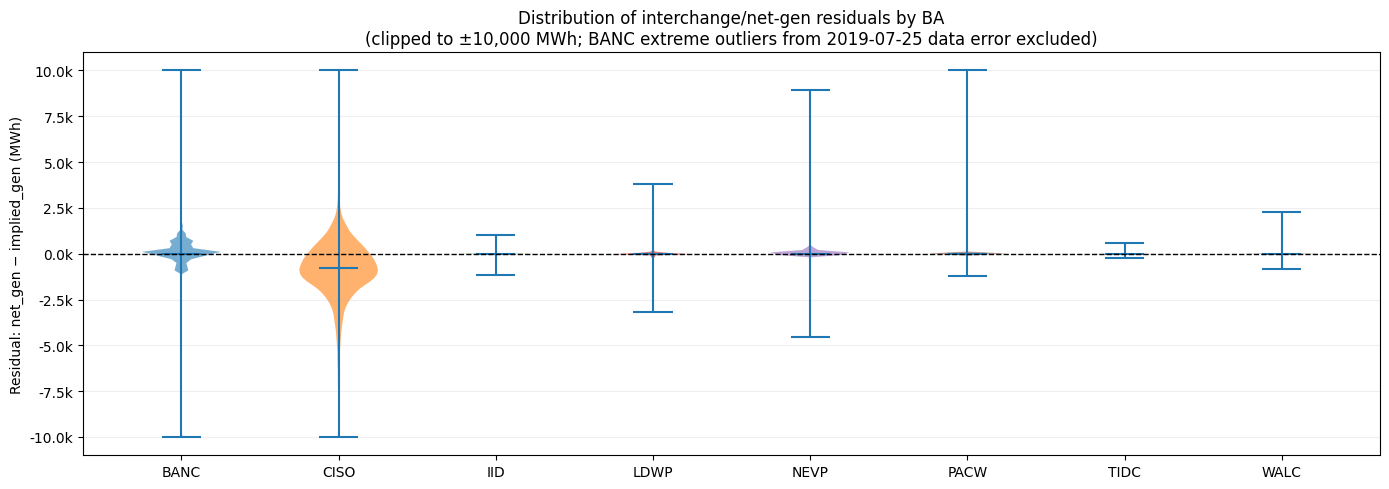

Residual summary (clipped at ±10,000 MWh):
             mean  median     std    pct5   pct95
respondent                                       
BANC          9.9     0.0   124.4    -3.0    16.0
CISO       -929.1  -781.0  1794.1 -3969.0  1436.0
IID          -5.6     0.0    67.9   -72.0    31.0
LDWP          6.1     0.0   240.3  -187.0    89.0
NEVP         17.7     0.0   274.0     0.0   162.0
PACW          8.1     0.0   128.2     0.0     0.0
TIDC          0.1    -1.0    21.4    -5.0     2.0
WALC          7.5     0.0    97.2     0.0     0.0


In [109]:
# Distribution of residuals per BA (violin / box)
fig, ax = plt.subplots(figsize=(14, 5))
data_for_violin = [
    bf[bf.respondent == ba]['residual_clipped'].dropna().values for ba in CA8
]
parts = ax.violinplot(data_for_violin, positions=range(len(CA8)),
                      showmedians=True, showextrema=True)
for i, (pc, ba) in enumerate(zip(parts['bodies'], CA8)):
    pc.set_facecolor(BA_COLOR[ba])
    pc.set_alpha(0.6)
ax.axhline(0, color='black', lw=1, ls='--')
ax.set_xticks(range(len(CA8)))
ax.set_xticklabels(CA8)
ax.set_ylabel('Residual: net_gen − implied_gen (MWh)')
ax.set_title(
    f'Distribution of interchange/net-gen residuals by BA\n'
    f'(clipped to ±{CLIP:,} MWh; BANC extreme outliers from 2019-07-25 data error excluded)'
)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{v/1000:.1f}k'))
ax.grid(True, alpha=0.2, axis='y')
plt.tight_layout()
plt.show()

print('Residual summary (clipped at ±10,000 MWh):')
print(
    bf.groupby('respondent')['residual_clipped']
    .agg(mean='mean', median='median', std='std',
         pct5=lambda x: x.quantile(0.05), pct95=lambda x: x.quantile(0.95))
    .round(1)
    .to_string()
)

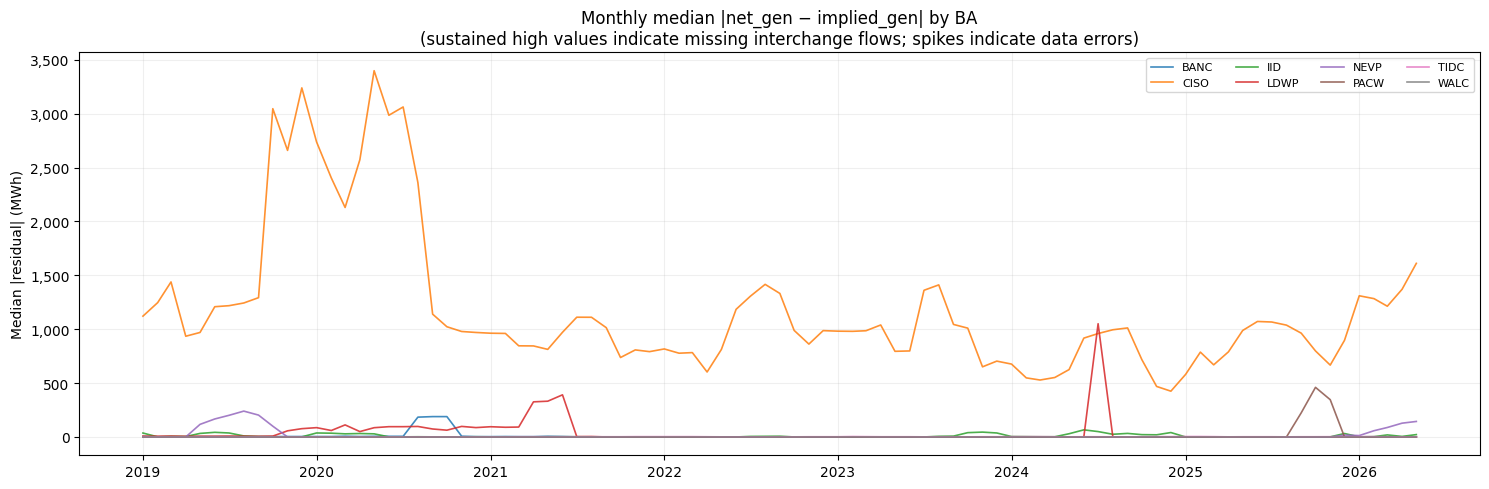

Top 10 worst residual hours (excluding BANC 2019-07-25 3.3 TW error):
respondent                  dt  demand  net_gen  implied_gen  gen_residual
      BANC 2019-04-07 04:00:00  1670.0   1788.0     528693.0     -526905.0
      PACW 2019-05-07 18:00:00  2256.0    980.0    -104426.0      105406.0
      CISO 2023-11-10 04:00:00 27244.0   3279.0      22494.0      -19215.0
      CISO 2023-11-10 03:00:00 27528.0   4060.0      23104.0      -19044.0
      CISO 2023-11-10 05:00:00 26415.0   3002.0      21520.0      -18518.0
      CISO 2023-11-10 06:00:00 25740.0   2372.0      20373.0      -18001.0
      CISO 2023-11-10 07:00:00 25185.0   2176.0      20033.0      -17857.0
      CISO 2023-11-10 08:00:00 23851.0   1794.0      18950.0      -17156.0
      CISO 2023-11-10 02:00:00 25729.0   5358.0      21757.0      -16399.0
      CISO 2025-07-31 21:00:00 11819.0  27732.0      11504.0       16228.0


In [110]:
# Monthly trend of median |residual| — shows if data quality changed over time
bf['month_dt'] = bf['dt'].dt.to_period('M').dt.to_timestamp()
monthly_resid = (
    bf.groupby(['respondent', 'month_dt'])['residual_clipped']
    .agg(median_abs=lambda x: x.abs().median())
    .reset_index()
)

fig, ax = plt.subplots(figsize=(15, 5))
for ba in CA8:
    d = monthly_resid[monthly_resid.respondent == ba]
    ax.plot(d.month_dt, d.median_abs, label=ba, color=BA_COLOR[ba], lw=1.2, alpha=0.85)
ax.set_ylabel('Median |residual| (MWh)')
ax.set_title(
    'Monthly median |net_gen − implied_gen| by BA\n'
    '(sustained high values indicate missing interchange flows; '
    'spikes indicate data errors)'
)
ax.legend(ncol=4, fontsize=8)
ax.grid(True, alpha=0.2)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f'{v:,.0f}'))
plt.tight_layout()
plt.show()

# Top 10 worst hours overall (excluding the known BANC 3.3 TW data error)
bf_filtered = bf[bf['gen_residual'].abs() < 1e6].copy()
bf_filtered['abs_residual'] = bf_filtered['gen_residual'].abs()
worst = bf_filtered.nlargest(10, 'abs_residual')[
    ['respondent', 'dt', 'demand', 'net_gen', 'implied_gen', 'gen_residual']
]
print('Top 10 worst residual hours (excluding BANC 2019-07-25 3.3 TW error):')
print(worst.round(0).to_string(index=False))

---
##PacifiCorp Substations Within California

PacifiCorp's T&D layer covers Oregon, Washington, Idaho, Utah, Wyoming, and
a small corner of northern California (the Redding / Mount Shasta area, served
by Pacific Power).  Filtering by California geographic bounds
(lat 32.5–42.1, lon −124.5–−114.0) isolates these.

PacifiCorp in California operates under the `PACW` balancing authority and
contributes to the CAISO EIM (Energy Imbalance Market).  Their California
footprint is within the BANC / PACW boundary region.

PacifiCorp substations in California: 62
PacifiCorp substations outside California: 1080

CA substations lat range: 40.94 – 42.10
CA substations lon range: -124.21 – -120.18
existing_der: 2/62 CA substations have data
net_min_daytime_load_mw: 2/62 CA substations have data


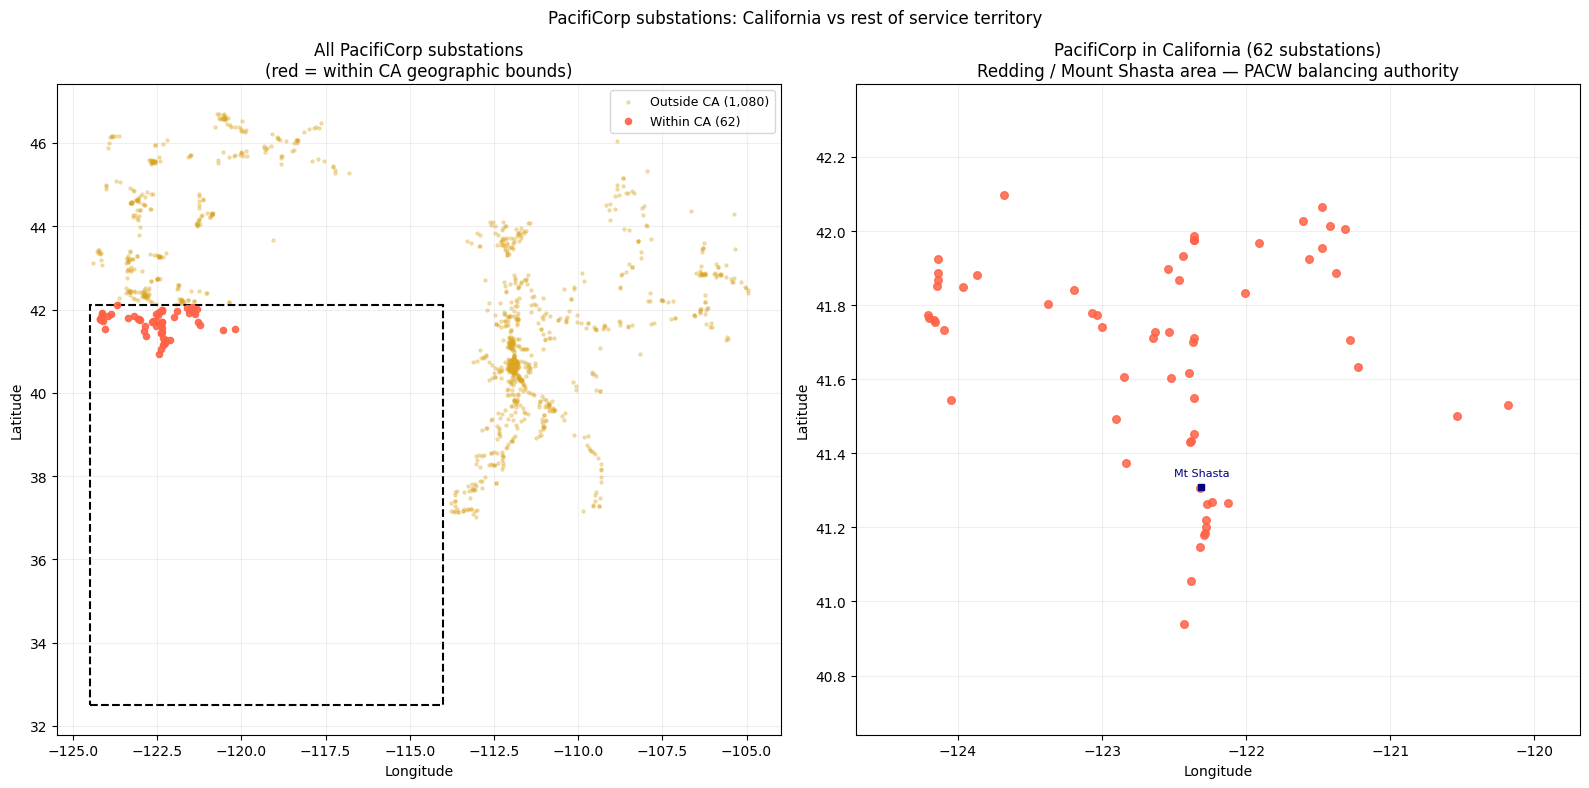

In [111]:
pac_all = loc[loc.utility == 'pacificorp'].dropna(subset=['latitude','longitude']).copy()
ca_bounds = dict(lat_min=32.5, lat_max=42.1, lon_min=-124.5, lon_max=-114.0)
in_ca = (
    (pac_all.latitude  >= ca_bounds['lat_min']) &
    (pac_all.latitude  <= ca_bounds['lat_max']) &
    (pac_all.longitude >= ca_bounds['lon_min']) &
    (pac_all.longitude <= ca_bounds['lon_max'])
)
pac_ca    = pac_all[in_ca]
pac_other = pac_all[~in_ca]

print(f'PacifiCorp substations in California: {len(pac_ca)}')
print(f'PacifiCorp substations outside California: {len(pac_other)}')
print(f'\nCA substations lat range: {pac_ca.latitude.min():.2f} – {pac_ca.latitude.max():.2f}')
print(f'CA substations lon range: {pac_ca.longitude.min():.2f} – {pac_ca.longitude.max():.2f}')

# Check DER data coverage for CA substations
der_cols = ['existing_der', 'net_min_daytime_load_mw']
for col in der_cols:
    pac_ca2 = pac_ca.copy()
    pac_ca2[col] = pd.to_numeric(pac_ca2[col], errors='coerce')
    n_have = pac_ca2[col].notna().sum()
    print(f'{col}: {n_have}/{len(pac_ca)} CA substations have data')

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Left: all PacifiCorp (CA highlighted)
ax = axes[0]
ax.scatter(pac_other.longitude, pac_other.latitude,
           s=5, alpha=0.3, color='goldenrod', label=f'Outside CA ({len(pac_other):,})')
ax.scatter(pac_ca.longitude, pac_ca.latitude,
           s=20, alpha=0.9, color='tomato', zorder=4, label=f'Within CA ({len(pac_ca)})')
# Draw approximate CA border box
import matplotlib.patches as mpatches
rect = mpatches.Rectangle(
    (ca_bounds['lon_min'], ca_bounds['lat_min']),
    ca_bounds['lon_max'] - ca_bounds['lon_min'],
    ca_bounds['lat_max'] - ca_bounds['lat_min'],
    linewidth=1.5, edgecolor='black', facecolor='none', linestyle='--'
)
ax.add_patch(rect)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('All PacifiCorp substations\n(red = within CA geographic bounds)')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.2)

# Right: zoom into CA substations
ax = axes[1]
ax.scatter(pac_ca.longitude, pac_ca.latitude,
           s=30, alpha=0.85, color='tomato', zorder=4)
ax.set_xlim(pac_ca.longitude.min() - 0.5, pac_ca.longitude.max() + 0.5)
ax.set_ylim(pac_ca.latitude.min() - 0.3, pac_ca.latitude.max() + 0.3)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title(f'PacifiCorp in California ({len(pac_ca)} substations)\n'
             f'Redding / Mount Shasta area — PACW balancing authority')
ax.grid(True, alpha=0.2)

# Annotate a few city reference points in the zoom
for city, clat, clon in [('Redding', 40.59, -122.39), ('Mt Shasta', 41.31, -122.31)]:
    ax.annotate(city, (clon, clat), fontsize=8, ha='center',
                xytext=(0, 8), textcoords='offset points', color='navy')
    ax.plot(clon, clat, 's', color='navy', ms=5, zorder=5)

plt.suptitle('PacifiCorp substations: California vs rest of service territory')
plt.tight_layout()
plt.show()